Mounted at /content/drive
OBELiX cohort/figure notebook version: 2026-07-19-v1
Compute device: Tesla T4
 cohort  n_train  n_test  n_train_groups
primary      212      48              92
 strict      198      43              92
  exact      133      35              75

[strict] fixed primary-train hyperparameters for static_rbf

[strict] fixed primary-train hyperparameters for li_wasserstein

[strict] fixed primary-train hyperparameters for total_wasserstein

[strict] fixed primary-train hyperparameters for static_plus_li_wasserstein

[exact] fixed primary-train hyperparameters for static_rbf

[exact] fixed primary-train hyperparameters for li_wasserstein

[exact] fixed primary-train hyperparameters for total_wasserstein

[exact] fixed primary-train hyperparameters for static_plus_li_wasserstein


ValueError: 'yerr' must not contain negative values

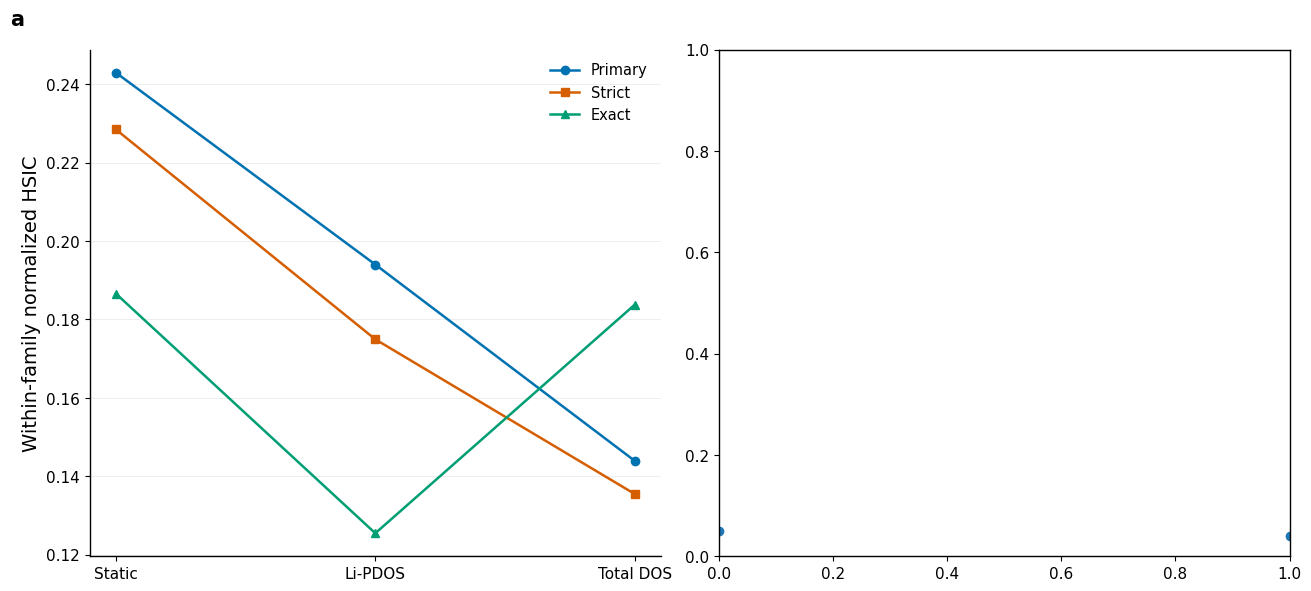

In [1]:
# OBELiX COHORT-SENSITIVITY + COMPLETE FIGURE GENERATION — SINGLE GOOGLE COLAB CELL
# Version: 2026-07-19-v1
#
# This cell:
#   1. reads the final audit-filtered output ZIP and driver tables from Drive;
#   2. normalizes chemical-family labels and fixes explicit exclusion reasons;
#   3. recomputes strict- and exact-cohort compact/frequency associations;
#   4. recomputes strict- and exact-cohort HSIC and principal kernel models;
#   5. generates all main-text and Supplementary figures;
#   6. writes the exact plotted data to CSV for every panel;
#   7. copies reference curves into the reproducibility package;
#   8. creates figure/completeness manifests and a downloadable ZIP.
#
# No existing production spectra, audit tables, or prior outputs are modified.

# ================================ CONFIGURATION ================================
from pathlib import Path

ANALYSIS_ROOT = Path(
    "/content/drive/MyDrive/OBELiX_convergence_outputs/"
    "audit_filtered_publication_analysis"
)
FINAL_RESULTS_ZIP = ANALYSIS_ROOT / "OBELiX_audit_filtered_publication_outputs.zip"
DRIVER_TABLES_DIR = ANALYSIS_ROOT / "driver_tables"
OUTPUT_ROOT = ANALYSIS_ROOT / "cohort_sensitivity_and_figures"
LOCAL_WORK = Path("/content/obelix_cohort_sensitivity_and_figures")
LOCAL_EXTRACTED = LOCAL_WORK / "extracted_final_results"

# Analysis settings. These are publication defaults; reduce only for debugging.
RANDOM_SEED = 20260719
PRIMARY_CENSOR_POLICY = "limit"
FREQ_MIN_THz = 0.0
FREQ_MAX_THz = 100.0
MAIN_FREQ_MAX_THz = 40.0
WASSERSTEIN_QUANTILES = 256
INNER_FOLDS = 4
OUTER_FOLDS_FOR_OOF = 5
N_BOOTSTRAP = 3000
N_COMPACT_BOOTSTRAP = 3000
N_ASSOCIATION_PERMUTATIONS = 5000
N_HSIC_PERMUTATIONS = 5000
HSIC_BATCH_SIZE = 64
FIGURE_DPI = 600
# False isolates the effect of cohort filtering by reusing hyperparameters selected
# on the original training cohort. Set True for a slower train-only retuning.
RETUNE_SENSITIVITY_MODELS = False
ZIP_NAME = "OBELiX_cohort_sensitivity_and_complete_figures.zip"

# Principal cohort-sensitivity models. The broad primary-cohort model comparison
# is read from the completed output ZIP; strict/exact reruns focus on the models
# needed for the central conclusions.
SENSITIVITY_MODEL_NAMES = (
    "static_rbf",
    "li_wasserstein",
    "total_wasserstein",
    "static_plus_li_wasserstein",
)

ALPHA_GRID = __import__("numpy").logspace(-5, 3, 7)
SINGLE_KERNEL_SCALE_GRID = (0.25, 0.5, 1.0, 2.0, 4.0)
ADDITIVE_KERNEL_SCALE_GRID = (0.5, 1.0, 2.0)
TWO_KERNEL_WEIGHT_GRID = tuple(__import__("numpy").linspace(0.0, 1.0, 6))

# ============================== PACKAGE INSTALLATION ===========================
import sys, subprocess
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "numpy>=1.26", "pandas>=2.0", "scipy>=1.11", "scikit-learn>=1.4",
    "matplotlib>=3.8", "statsmodels>=0.14", "pyyaml>=6.0"
])

# =================================== IMPORTS ===================================
import os
import re
import io
import gc
import json
import math
import shutil
import zipfile
import hashlib
import warnings
import itertools
import zlib
from dataclasses import dataclass
from collections import defaultdict
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy import stats
from scipy.interpolate import interp1d
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# ================================ MOUNT DRIVE ==================================
from google.colab import drive, files

drive.mount("/content/drive", force_remount=True)
print("OBELiX cohort/figure notebook version: 2026-07-19-v1")

# =============================== DEVICE / SEEDS ================================
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DTYPE = torch.float64
print("Compute device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

# =============================== OUTPUT FOLDERS ================================
if LOCAL_WORK.exists():
    shutil.rmtree(LOCAL_WORK)
LOCAL_WORK.mkdir(parents=True, exist_ok=True)
LOCAL_EXTRACTED.mkdir(parents=True, exist_ok=True)

if OUTPUT_ROOT.exists():
    shutil.rmtree(OUTPUT_ROOT)
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

MAIN_FIGURES = OUTPUT_ROOT / "main_figures"
SUPP_FIGURES = OUTPUT_ROOT / "supplementary_figures"
MAIN_DATA = OUTPUT_ROOT / "plot_data" / "main"
SUPP_DATA = OUTPUT_ROOT / "plot_data" / "supplement"
TABLES = OUTPUT_ROOT / "tables"
LOGS = OUTPUT_ROOT / "logs"
REPRO = OUTPUT_ROOT / "reproducibility"
REFERENCE_CURVES = REPRO / "reference_curves"
for d in [MAIN_FIGURES, SUPP_FIGURES, MAIN_DATA, SUPP_DATA, TABLES, LOGS, REPRO, REFERENCE_CURVES]:
    d.mkdir(parents=True, exist_ok=True)

# =============================== INPUT VALIDATION ===============================
if not FINAL_RESULTS_ZIP.exists():
    raise FileNotFoundError(f"Final result ZIP not found:\n{FINAL_RESULTS_ZIP}")
if not DRIVER_TABLES_DIR.exists():
    raise FileNotFoundError(f"Driver-table directory not found:\n{DRIVER_TABLES_DIR}")

with zipfile.ZipFile(FINAL_RESULTS_ZIP, "r") as zf:
    zf.extractall(LOCAL_EXTRACTED)

ASSOC_ROOT = LOCAL_EXTRACTED / "association_results"
KERNEL_ROOT = LOCAL_EXTRACTED / "kernel_results"
REVIEWER_ROOT = LOCAL_EXTRACTED / "reviewer_response_results"
for required in [ASSOC_ROOT, KERNEL_ROOT, REVIEWER_ROOT]:
    if not required.exists():
        raise RuntimeError(f"Expected result directory missing after extraction: {required}")

# ================================ STYLE HELPERS =================================
plt.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 14,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 10.5,
    "axes.linewidth": 1.0,
    "lines.linewidth": 1.8,
    "lines.markersize": 6,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "savefig.transparent": False,
})

# Color-blind-friendly palette. Marker shapes retain meaning in grayscale.
COLORS = {
    "primary": "#0072B2",
    "strict": "#D55E00",
    "exact": "#009E73",
    "train": "#0072B2",
    "test": "#D55E00",
    "Li": "#0072B2",
    "total": "#E69F00",
    "static": "#666666",
    "model": "#0072B2",
    "reference": "#D55E00",
}
MARKERS = {"primary": "o", "strict": "s", "exact": "^", "train": "o", "test": "s"}

figure_manifest_rows = []
analysis_manifest_rows = []


def sanitize_name(text):
    text = re.sub(r"[^A-Za-z0-9_.-]+", "_", str(text)).strip("_")
    return text or "unnamed"


def register_analysis(name, status, reason="", outputs=""):
    analysis_manifest_rows.append({
        "analysis": name,
        "status": status,
        "reason": reason,
        "outputs": outputs,
    })


def save_panel(fig, stem, data_frames, location="main", annotations=None):
    """Save PDF, PNG, exact plotted CSV(s), and optional annotations CSV."""
    fig_dir = MAIN_FIGURES if location == "main" else SUPP_FIGURES
    data_dir = MAIN_DATA if location == "main" else SUPP_DATA
    stem = sanitize_name(stem)
    pdf = fig_dir / f"{stem}.pdf"
    png = fig_dir / f"{stem}.png"
    fig.savefig(pdf, bbox_inches="tight")
    fig.savefig(png, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.close(fig)

    csv_paths = []
    if isinstance(data_frames, pd.DataFrame):
        data_frames = {stem: data_frames}
    for suffix, frame in data_frames.items():
        p = data_dir / f"{stem}__{sanitize_name(suffix)}.csv"
        frame.to_csv(p, index=False)
        csv_paths.append(str(p.relative_to(OUTPUT_ROOT)))
    ann_path = ""
    if annotations is not None:
        ann = pd.DataFrame(annotations)
        p = data_dir / f"{stem}__annotations.csv"
        ann.to_csv(p, index=False)
        ann_path = str(p.relative_to(OUTPUT_ROOT))

    figure_manifest_rows.append({
        "location": location,
        "figure_stem": stem,
        "pdf": str(pdf.relative_to(OUTPUT_ROOT)),
        "png": str(png.relative_to(OUTPUT_ROOT)),
        "plot_data_csvs": ";".join(csv_paths),
        "annotations_csv": ann_path,
    })


def panel_label(ax, label):
    ax.text(-0.14, 1.04, label, transform=ax.transAxes, fontsize=15,
            fontweight="bold", va="bottom", ha="left", clip_on=False)


def clean_axes(ax, grid_axis=None):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    if grid_axis:
        ax.grid(axis=grid_axis, alpha=0.22, linewidth=0.7)


def add_zero_line(ax, orientation="h"):
    if orientation == "h":
        ax.axhline(0, color="0.25", linewidth=0.9, zorder=0)
    else:
        ax.axvline(0, color="0.25", linewidth=0.9, zorder=0)

# ============================== GENERIC UTILITIES ===============================
def read_csv_required(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, dtype={"ID": str})


def normalize_id(x):
    return str(x).strip().lower()


def normalize_family(value):
    if pd.isna(value):
        return "Unknown"
    x = str(value).strip()
    if not x or x.lower() in {"nan", "none", "unknown"}:
        return "Unknown"
    key = re.sub(r"[^a-z0-9]+", "", x.lower())
    mapping = {
        "argyrodite": "argyrodites", "argyrodites": "argyrodites",
        "garnet": "garnet", "garnets": "garnet",
        "halide": "halides", "halides": "halides", "chloride": "halides",
        "chlorides": "halides", "cholorides": "halides",
        "nitride": "nitrides", "nitrides": "nitrides",
        "oxide": "oxides", "oxides": "oxides",
        "phosphate": "phosphates", "phosphates": "phosphates",
        "perovskite": "perovskites", "perovskites": "perovskites",
        "lisicon": "LISICON", "nasicon": "NASICON", "lgps": "LGPS",
    }
    return mapping.get(key, x)


def row_normalize(X):
    X = np.asarray(X, float)
    X = np.clip(np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0), 0.0, None)
    s = X.sum(axis=1, keepdims=True)
    return np.divide(X, s, out=np.zeros_like(X), where=s > 0)


def quantile_embedding(P, centers, n_quantiles=WASSERSTEIN_QUANTILES):
    P = row_normalize(P)
    u = (np.arange(n_quantiles) + 0.5) / n_quantiles
    out = np.empty((P.shape[0], n_quantiles), float)
    for i, row in enumerate(P):
        cdf = np.cumsum(row)
        if cdf[-1] <= 0:
            out[i] = 0.0
            continue
        cdf[-1] = 1.0
        idx = np.searchsorted(cdf, u, side="left")
        idx = np.clip(idx, 0, len(centers) - 1)
        out[i] = centers[idx]
    return out


def safe_spearman(x, y):
    x, y = np.asarray(x, float), np.asarray(y, float)
    valid = np.isfinite(x) & np.isfinite(y)
    if valid.sum() < 3 or np.nanstd(x[valid]) == 0 or np.nanstd(y[valid]) == 0:
        return np.nan, np.nan
    r = stats.spearmanr(x[valid], y[valid])
    return float(r.statistic), float(r.pvalue)


def bootstrap_spearman(x, y, n_boot=N_COMPACT_BOOTSTRAP, seed=RANDOM_SEED):
    x, y = np.asarray(x, float), np.asarray(y, float)
    valid = np.isfinite(x) & np.isfinite(y)
    x, y = x[valid], y[valid]
    rho, p = safe_spearman(x, y)
    if len(x) < 4:
        return rho, np.nan, np.nan, p
    rng = np.random.default_rng(seed)
    vals = np.empty(n_boot, float)
    for b in range(n_boot):
        idx = rng.integers(0, len(x), len(x))
        vals[b] = safe_spearman(x[idx], y[idx])[0]
    return rho, float(np.nanpercentile(vals, 2.5)), float(np.nanpercentile(vals, 97.5)), p


def metric_dict(y, pred):
    y, pred = np.asarray(y, float), np.asarray(pred, float)
    return {
        "MAE": float(mean_absolute_error(y, pred)),
        "RMSE": float(math.sqrt(mean_squared_error(y, pred))),
        "R2": float(r2_score(y, pred)),
        "Spearman_rho": float(stats.spearmanr(y, pred).statistic),
    }


def metric_value(metric, y, pred):
    return metric_dict(y, pred)[metric]

# ============================= LOAD DRIVER TABLES ===============================
driver_files = {
    "master": DRIVER_TABLES_DIR / "cohort_master_manifest.csv",
    "primary": DRIVER_TABLES_DIR / "cohort_included_primary.csv",
    "strict": DRIVER_TABLES_DIR / "cohort_included_strict.csv",
    "exact": DRIVER_TABLES_DIR / "cohort_included_exact.csv",
    "exclusions": DRIVER_TABLES_DIR / "cohort_exclusions.csv",
    "audit": DRIVER_TABLES_DIR / "audit_with_analysis_eligibility.csv",
    "reference_resolution": DRIVER_TABLES_DIR / "reference_manifest_file_resolution.csv",
}
DRIVERS = {k: read_csv_required(v) for k, v in driver_files.items()}
for df in DRIVERS.values():
    if "ID" in df.columns:
        df["ID"] = df["ID"].map(normalize_id)
    family_col = "Family" if "Family" in df.columns else ("family" if "family" in df.columns else None)
    if family_col:
        df["Family_normalized"] = df[family_col].map(normalize_family)

# Correct missing exclusion reasons explicitly and preserve the correction.
exclusions = DRIVERS["exclusions"].copy()
if "primary_exclusion_reason" not in exclusions.columns:
    exclusions["primary_exclusion_reason"] = ""
missing_reason = exclusions["primary_exclusion_reason"].fillna("").str.strip().eq("")
exclusions.loc[missing_reason, "primary_exclusion_reason"] = "missing_audit_record_or_unclassified_exclusion"
exclusions.to_csv(TABLES / "cohort_exclusions_with_explicit_reasons.csv", index=False)

# Normalized cohort tables.
COHORTS = {}
for name in ["primary", "strict", "exact"]:
    df = DRIVERS[name].copy()
    df["ID"] = df["ID"].map(normalize_id)
    family_col = "Family" if "Family" in df.columns else "family"
    df["Family_normalized"] = df[family_col].map(normalize_family)
    df.to_csv(TABLES / f"cohort_{name}_family_normalized.csv", index=False)
    COHORTS[name] = df

cohort_count_rows = []
for name, df in COHORTS.items():
    for split, n in df["split"].value_counts().items():
        cohort_count_rows.append({"cohort": name, "split": split, "n": int(n)})
cohort_counts = pd.DataFrame(cohort_count_rows)
cohort_counts.to_csv(TABLES / "cohort_counts.csv", index=False)

# ============================= LOAD EXISTING RESULTS ============================
train_li = read_csv_required(ASSOC_ROOT / "features" / "train_li_shape_1THz.csv").set_index("ID")
test_li = read_csv_required(ASSOC_ROOT / "features" / "test_li_shape_1THz.csv").set_index("ID")
train_total = read_csv_required(ASSOC_ROOT / "features" / "train_total_shape_1THz.csv").set_index("ID")
test_total = read_csv_required(ASSOC_ROOT / "features" / "test_total_shape_1THz.csv").set_index("ID")
static_all = read_csv_required(ASSOC_ROOT / "features" / "composition_and_static_confounders.csv").set_index("ID")
train_scalar = read_csv_required(REVIEWER_ROOT / "tables" / "train_all_scalar_phonon_descriptors.csv").set_index("ID")
test_scalar = read_csv_required(REVIEWER_ROOT / "tables" / "test_all_scalar_phonon_descriptors.csv").set_index("ID")

li_cols = [c for c in train_li.columns if c.startswith("LiPDOS_")]
total_cols = [c for c in train_total.columns if c.startswith("TotalDOS_") or c.startswith("totalDOS_")]
if not total_cols:
    total_cols = [c for c in train_total.columns if c != "ID"]
static_cols = [c for c in static_all.columns if c != "ID"]

# Parse frequency centers from feature names.
def parse_bin_center(col):
    nums = re.findall(r"([0-9]+(?:\.[0-9]+)?)", str(col))
    if len(nums) >= 2:
        return 0.5 * (float(nums[-2]) + float(nums[-1]))
    return np.nan

FREQ_CENTERS = np.asarray([parse_bin_center(c) for c in li_cols], float)
BIN_WIDTH = float(np.nanmedian(np.diff(FREQ_CENTERS)))

# ========================== LEAKAGE-GROUP CONSTRUCTION ==========================
class UnionFind:
    def __init__(self, n):
        self.parent = list(range(n))
        self.rank = [0] * n
    def find(self, x):
        while self.parent[x] != x:
            self.parent[x] = self.parent[self.parent[x]]
            x = self.parent[x]
        return x
    def union(self, a, b):
        ra, rb = self.find(a), self.find(b)
        if ra == rb:
            return
        if self.rank[ra] < self.rank[rb]:
            ra, rb = rb, ra
        self.parent[rb] = ra
        if self.rank[ra] == self.rank[rb]:
            self.rank[ra] += 1


def leakage_groups(meta):
    meta = meta.reset_index(drop=True)
    uf = UnionFind(len(meta))
    for col in ["Reduced Composition", "DOI"]:
        if col not in meta.columns:
            continue
        buckets = defaultdict(list)
        for i, val in enumerate(meta[col].fillna("").astype(str).str.strip()):
            if val and val.lower() not in {"nan", "none"}:
                buckets[val.lower()].append(i)
        for inds in buckets.values():
            for j in inds[1:]:
                uf.union(inds[0], j)
    roots = [uf.find(i) for i in range(len(meta))]
    mapping = {r: k for k, r in enumerate(sorted(set(roots)))}
    return np.asarray([mapping[r] for r in roots], int)


@dataclass
class CohortContext:
    name: str
    train_ids: np.ndarray
    test_ids: np.ndarray
    y_train: np.ndarray
    y_test: np.ndarray
    family_train: np.ndarray
    family_test: np.ndarray
    groups_train: np.ndarray
    meta_train: pd.DataFrame
    meta_test: pd.DataFrame
    arrays_train: dict
    arrays_test: dict


def build_context(name, cohort_df):
    cohort_df = cohort_df.copy()
    cohort_df["ID"] = cohort_df["ID"].map(normalize_id)
    target = f"log10_ic_{PRIMARY_CENSOR_POLICY}"
    train_meta = cohort_df[cohort_df["split"].eq("train")].set_index("ID", drop=False)
    test_meta = cohort_df[cohort_df["split"].eq("test")].set_index("ID", drop=False)

    train_ids = train_meta.index.intersection(train_li.index).intersection(train_total.index).intersection(static_all.index)
    test_ids = test_meta.index.intersection(test_li.index).intersection(test_total.index).intersection(static_all.index)
    train_ids = train_ids[np.isfinite(pd.to_numeric(train_meta.loc[train_ids, target], errors="coerce"))]
    test_ids = test_ids[np.isfinite(pd.to_numeric(test_meta.loc[test_ids, target], errors="coerce"))]

    li_tr = row_normalize(train_li.loc[train_ids, li_cols].apply(pd.to_numeric, errors="coerce"))
    li_te = row_normalize(test_li.loc[test_ids, li_cols].apply(pd.to_numeric, errors="coerce"))
    total_tr = row_normalize(train_total.loc[train_ids, total_cols].apply(pd.to_numeric, errors="coerce"))
    total_te = row_normalize(test_total.loc[test_ids, total_cols].apply(pd.to_numeric, errors="coerce"))
    static_tr = static_all.loc[train_ids, static_cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)
    static_te = static_all.loc[test_ids, static_cols].apply(pd.to_numeric, errors="coerce").to_numpy(float)

    mt = train_meta.loc[train_ids].copy()
    me = test_meta.loc[test_ids].copy()
    return CohortContext(
        name=name,
        train_ids=np.asarray(train_ids),
        test_ids=np.asarray(test_ids),
        y_train=pd.to_numeric(mt[target], errors="coerce").to_numpy(float),
        y_test=pd.to_numeric(me[target], errors="coerce").to_numpy(float),
        family_train=mt["Family_normalized"].to_numpy(str),
        family_test=me["Family_normalized"].to_numpy(str),
        groups_train=leakage_groups(mt),
        meta_train=mt,
        meta_test=me,
        arrays_train={
            "li_raw": li_tr,
            "li_w2": quantile_embedding(li_tr, FREQ_CENTERS),
            "total_raw": total_tr,
            "total_w2": quantile_embedding(total_tr, FREQ_CENTERS),
            "static": static_tr,
        },
        arrays_test={
            "li_raw": li_te,
            "li_w2": quantile_embedding(li_te, FREQ_CENTERS),
            "total_raw": total_te,
            "total_w2": quantile_embedding(total_te, FREQ_CENTERS),
            "static": static_te,
        },
    )


CONTEXTS = {name: build_context(name, df) for name, df in COHORTS.items()}
context_rows = []
for name, ctx in CONTEXTS.items():
    context_rows.append({"cohort": name, "n_train": len(ctx.train_ids), "n_test": len(ctx.test_ids),
                         "n_train_groups": len(np.unique(ctx.groups_train))})
pd.DataFrame(context_rows).to_csv(TABLES / "analysis_context_counts.csv", index=False)
print(pd.DataFrame(context_rows).to_string(index=False))

# ============================ COHORT ASSOCIATIONS ===============================
PREDECLARED_DESCRIPTORS = [
    "Li_fraction_below_2THz", "Li_fraction_below_5THz", "Li_q05_THz", "Li_centroid_THz",
    "total_fraction_below_2THz", "total_fraction_below_5THz", "total_q05_THz", "total_centroid_THz",
]

compact_rows = []
frequency_rows = []
maxT_null_rows = []


def compute_compact_associations(ctx):
    for split, ids, y, scalars in [
        ("train", ctx.train_ids, ctx.y_train, train_scalar),
        ("test", ctx.test_ids, ctx.y_test, test_scalar),
    ]:
        available = [d for d in PREDECLARED_DESCRIPTORS if d in scalars.columns]
        for j, descriptor in enumerate(available):
            x = pd.to_numeric(scalars.loc[ids, descriptor], errors="coerce").to_numpy(float)
            rho, lo, hi, p = bootstrap_spearman(
                x, y, n_boot=N_COMPACT_BOOTSTRAP,
                seed=RANDOM_SEED + 1000 * (1 if split == "train" else 2) + j + 100 * list(CONTEXTS).index(ctx.name),
            )
            compact_rows.append({
                "cohort": ctx.name, "split": split, "descriptor": descriptor,
                "n": int(np.sum(np.isfinite(x) & np.isfinite(y))),
                "spearman_rho": rho, "ci95_low": lo, "ci95_high": hi,
                "p_analytic": p,
            })


def maxT_spearman_pvalues(X, y, n_perm, seed):
    X = np.asarray(X, float)
    y = np.asarray(y, float)
    # Column-wise rank transform followed by standardization.
    RX = np.column_stack([stats.rankdata(X[:, j], method="average") for j in range(X.shape[1])])
    RY = stats.rankdata(y, method="average")
    RX = (RX - RX.mean(axis=0)) / np.where(RX.std(axis=0, ddof=1) > 0, RX.std(axis=0, ddof=1), 1.0)
    RY = (RY - RY.mean()) / max(RY.std(ddof=1), 1e-12)
    observed = (RY[:, None] * RX).sum(axis=0) / max(len(y) - 1, 1)
    rng = np.random.default_rng(seed)
    max_null = np.empty(n_perm, float)
    batch = 256
    RX_t = torch.as_tensor(RX, dtype=DTYPE, device=DEVICE)
    for start in range(0, n_perm, batch):
        b = min(batch, n_perm - start)
        perms = np.vstack([rng.permutation(len(y)) for _ in range(b)])
        Yp = np.vstack([RY[p] for p in perms])
        Yp_t = torch.as_tensor(Yp, dtype=DTYPE, device=DEVICE)
        corr = (Yp_t @ RX_t) / max(len(y) - 1, 1)
        max_null[start:start+b] = torch.max(torch.abs(corr), dim=1).values.detach().cpu().numpy()
    pvals = (1.0 + np.sum(max_null[:, None] >= np.abs(observed)[None, :], axis=0)) / (n_perm + 1.0)
    return observed, pvals, max_null


def compute_frequency_associations(ctx, representation):
    if representation == "Li-PDOS":
        Xtr, Xte = ctx.arrays_train["li_raw"], ctx.arrays_test["li_raw"]
    else:
        Xtr, Xte = ctx.arrays_train["total_raw"], ctx.arrays_test["total_raw"]
    observed_rank, p_maxT, null = maxT_spearman_pvalues(
        Xtr, ctx.y_train, N_ASSOCIATION_PERMUTATIONS,
        RANDOM_SEED + 77 + list(CONTEXTS).index(ctx.name) * 17 + (0 if representation == "Li-PDOS" else 1),
    )
    maxT_null_rows.extend({"cohort": ctx.name, "representation": representation, "max_abs_rho": v} for v in null)
    for split, X, y in [("train", Xtr, ctx.y_train), ("test", Xte, ctx.y_test)]:
        for j, center in enumerate(FREQ_CENTERS):
            rho, p = safe_spearman(X[:, j], y)
            # Fisher-z approximation shown as a visual uncertainty band. Compact
            # descriptor CIs use the full bootstrap above.
            if np.isfinite(rho) and len(y) > 3 and abs(rho) < 0.999999:
                z = np.arctanh(rho)
                se = 1.0 / math.sqrt(max(len(y) - 3, 1))
                lo, hi = np.tanh(z - 1.96 * se), np.tanh(z + 1.96 * se)
            else:
                lo = hi = np.nan
            frequency_rows.append({
                "cohort": ctx.name, "split": split, "representation": representation,
                "bin_center_THz": center, "spearman_rho": rho,
                "ci95_low_approx": lo, "ci95_high_approx": hi,
                "p_analytic": p,
                "train_maxT_p": p_maxT[j] if split == "train" else np.nan,
                "n": len(y),
            })


for ctx in CONTEXTS.values():
    compute_compact_associations(ctx)
    compute_frequency_associations(ctx, "Li-PDOS")
    compute_frequency_associations(ctx, "Total DOS")

compact_df = pd.DataFrame(compact_rows)
frequency_df = pd.DataFrame(frequency_rows)
maxT_null_df = pd.DataFrame(maxT_null_rows)
compact_df.to_csv(TABLES / "cohort_sensitivity_compact_associations.csv", index=False)
frequency_df.to_csv(TABLES / "cohort_sensitivity_frequency_associations.csv", index=False)
maxT_null_df.to_csv(TABLES / "cohort_sensitivity_frequency_maxT_null.csv", index=False)
register_analysis("cohort compact/frequency associations", "generated", outputs="tables/cohort_sensitivity_*associations.csv")

# =============================== KERNEL MODELS ==================================
def to_tensor(x):
    return torch.as_tensor(np.asarray(x), dtype=DTYPE, device=DEVICE)


def squared_distances(A, B):
    return torch.cdist(to_tensor(A), to_tensor(B), p=2.0).pow(2)


def median_positive_distance(D2):
    n = D2.shape[0]
    inds = torch.triu_indices(n, n, offset=1, device=DEVICE)
    vals = D2[inds[0], inds[1]]
    vals = vals[vals > 1e-24]
    return float(torch.sqrt(torch.median(vals)).item()) if vals.numel() else 1.0


def normalize_kernel(Ktr, Kcross):
    scale = torch.clamp(torch.mean(torch.diagonal(Ktr)), min=1e-12)
    return Ktr / scale, Kcross / scale


def center_kernel(Ktr, Kcross):
    col_mean = Ktr.mean(dim=0, keepdim=True)
    row_mean = Ktr.mean(dim=1, keepdim=True)
    grand = Ktr.mean()
    return (Ktr - row_mean - col_mean + grand,
            Kcross - Kcross.mean(dim=1, keepdim=True) - col_mean + grand)


MODEL_SPECS = {
    "static_rbf": {"label": "Static RBF", "components": ("static_rbf",), "additive": False},
    "li_wasserstein": {"label": "Li-PDOS Wasserstein", "components": ("li_wasserstein",), "additive": False},
    "total_wasserstein": {"label": "Total-DOS Wasserstein", "components": ("total_wasserstein",), "additive": False},
    "static_plus_li_wasserstein": {"label": "Static + Li Wasserstein", "components": ("static_rbf", "li_wasserstein"), "additive": True},
}
COMPONENT_SOURCE = {
    "static_rbf": "static",
    "li_wasserstein": "li_w2",
    "total_wasserstein": "total_w2",
}


class KernelEngine:
    def __init__(self, ctx):
        self.ctx = ctx
        self.cache = {}

    def component(self, component, fit_idx, eval_idx, eval_split, scale_mult):
        fit_idx = np.asarray(fit_idx, int)
        eval_idx = np.asarray(eval_idx, int)
        key = (component, tuple(fit_idx), tuple(eval_idx), eval_split)
        if key not in self.cache:
            src = COMPONENT_SOURCE[component]
            Xfit = self.ctx.arrays_train[src][fit_idx]
            Xeval = self.ctx.arrays_train[src][eval_idx] if eval_split == "train" else self.ctx.arrays_test[src][eval_idx]
            if src == "static":
                imp = SimpleImputer(strategy="median")
                scaler = StandardScaler()
                Xfit = scaler.fit_transform(imp.fit_transform(Xfit))
                Xeval = scaler.transform(imp.transform(Xeval))
            Dtr = squared_distances(Xfit, Xfit)
            Dx = squared_distances(Xeval, Xfit)
            median = median_positive_distance(Dtr)
            self.cache[key] = (Dtr, Dx, median)
        Dtr, Dx, median = self.cache[key]
        ell = max(float(scale_mult) * median, 1e-12)
        return normalize_kernel(torch.exp(-Dtr / (2 * ell * ell)), torch.exp(-Dx / (2 * ell * ell)))

    def combined(self, spec, fit_idx, eval_idx, eval_split, scale_mult, weights):
        pairs = [self.component(c, fit_idx, eval_idx, eval_split, scale_mult) for c in spec["components"]]
        Ktr = torch.zeros_like(pairs[0][0])
        Kx = torch.zeros_like(pairs[0][1])
        for w, (a, b) in zip(weights, pairs):
            Ktr += float(w) * a
            Kx += float(w) * b
        return Ktr, Kx


def make_group_splits(indices, groups, n_splits, seed):
    indices = np.asarray(indices, int)
    local_groups = np.asarray(groups)[indices]
    unique = np.unique(local_groups)
    if len(unique) >= 3:
        splitter = GroupKFold(n_splits=min(n_splits, len(unique)))
        return [(indices[a], indices[b]) for a, b in splitter.split(indices, groups=local_groups)]
    splitter = KFold(n_splits=min(n_splits, max(2, len(indices) // 10)), shuffle=True, random_state=seed)
    return [(indices[a], indices[b]) for a, b in splitter.split(indices)]


def eig_predictions(Ktr, Kcross, y_train, alphas):
    Kc, Kxc = center_kernel(Ktr, Kcross)
    y = to_tensor(y_train)
    mean = y.mean()
    yc = y - mean
    eigvals, eigvecs = torch.linalg.eigh(Kc)
    eigvals = torch.clamp(eigvals, min=0.0)
    proj = eigvecs.T @ yc
    aa = to_tensor(np.asarray(alphas, float))
    coef = proj[:, None] / (eigvals[:, None] + aa[None, :])
    return (Kxc @ eigvecs @ coef + mean).detach().cpu().numpy()


def parameter_grid(spec):
    if len(spec["components"]) == 1:
        weights = [(1.0,)]
        scales = SINGLE_KERNEL_SCALE_GRID
    else:
        weights = [(1.0 - w, w) for w in TWO_KERNEL_WEIGHT_GRID]
        scales = ADDITIVE_KERNEL_SCALE_GRID
    return scales, weights


def tune_model(ctx, engine, spec, seed):
    all_idx = np.arange(len(ctx.y_train))
    splits = make_group_splits(all_idx, ctx.groups_train, INNER_FOLDS, seed)
    best = None
    rows = []
    scales, weights_grid = parameter_grid(spec)
    for scale in scales:
        for weights in weights_grid:
            fold_mae = np.zeros((len(splits), len(ALPHA_GRID)), float)
            for f, (tr, va) in enumerate(splits):
                Ktr, Kva = engine.combined(spec, tr, va, "train", scale, weights)
                pred = eig_predictions(Ktr, Kva, ctx.y_train[tr], ALPHA_GRID)
                fold_mae[f] = np.mean(np.abs(ctx.y_train[va, None] - pred), axis=0)
            mean = fold_mae.mean(axis=0)
            sd = fold_mae.std(axis=0, ddof=1) if len(splits) > 1 else np.zeros_like(mean)
            for i, alpha in enumerate(ALPHA_GRID):
                row = {"scale_mult": float(scale), "weights": tuple(float(v) for v in weights),
                       "alpha": float(alpha), "cv_MAE": float(mean[i]), "cv_MAE_sd": float(sd[i])}
                rows.append(row)
                key = (row["cv_MAE"], row["cv_MAE_sd"], -row["alpha"])
                if best is None or key < best[0]:
                    best = (key, row)
    return best[1], pd.DataFrame(rows)


def predict_params(ctx, engine, spec, fit_idx, eval_idx, eval_split, params):
    Ktr, Kx = engine.combined(spec, fit_idx, eval_idx, eval_split,
                             params["scale_mult"], params["weights"])
    return eig_predictions(Ktr, Kx, ctx.y_train[np.asarray(fit_idx, int)], [params["alpha"]])[:, 0]


def fixed_param_oof(ctx, engine, spec, params, seed):
    out = np.full(len(ctx.y_train), np.nan)
    splits = make_group_splits(np.arange(len(ctx.y_train)), ctx.groups_train, OUTER_FOLDS_FOR_OOF, seed)
    for tr, va in splits:
        out[va] = predict_params(ctx, engine, spec, tr, va, "train", params)
    return out


sensitivity_prediction_rows = []
sensitivity_metric_rows = []
sensitivity_hyper_rows = []
sensitivity_bootstrap_rows = []
sensitivity_paired_rows = []
static_oof_by_cohort = {}

# Primary results are already fully nested and are imported directly.
primary_pred = read_csv_required(KERNEL_ROOT / "predictions" / "all_kernel_predictions.csv")
primary_pred["ID"] = primary_pred["ID"].map(normalize_id)
primary_metrics = read_csv_required(KERNEL_ROOT / "tables" / "kernel_performance_summary.csv")
for model in SENSITIVITY_MODEL_NAMES:
    subset = primary_pred[primary_pred["model"].eq(model)].copy()
    subset["cohort"] = "primary"
    subset["Family_normalized"] = subset["Family"].map(normalize_family)
    sensitivity_prediction_rows.extend(subset.to_dict("records"))
    m = primary_metrics[(primary_metrics["model"].eq(model)) & (primary_metrics["evaluation"].eq("official_test"))]
    if len(m):
        sensitivity_metric_rows.append({"cohort": "primary", **m.iloc[0].to_dict()})
static_oof_primary = primary_pred[(primary_pred["model"].eq("static_rbf")) & (primary_pred["split"].eq("train_OOF"))]
static_oof_by_cohort["primary"] = dict(zip(static_oof_primary["ID"], static_oof_primary["observed"] - static_oof_primary["predicted"]))

primary_selected_hyperparameters = json.loads((KERNEL_ROOT / "selected_hyperparameters.json").read_text())

for cohort_name in ["strict", "exact"]:
    ctx = CONTEXTS[cohort_name]
    engine = KernelEngine(ctx)
    cohort_test_predictions = {}
    cohort_oof_predictions = {}
    for model_index, model_name in enumerate(SENSITIVITY_MODEL_NAMES):
        spec = MODEL_SPECS[model_name]
        if RETUNE_SENSITIVITY_MODELS:
            print(f"\n[{cohort_name}] train-only retuning {model_name}")
            params, search = tune_model(ctx, engine, spec, RANDOM_SEED + 1000 * (1 + model_index) + 10000 * (1 if cohort_name == "strict" else 2))
            search["cohort"] = cohort_name
            search["model"] = model_name
            search["parameter_source"] = "cohort_train_only_retuning"
            sensitivity_hyper_rows.extend(search.to_dict("records"))
        else:
            print(f"\n[{cohort_name}] fixed primary-train hyperparameters for {model_name}")
            raw = primary_selected_hyperparameters[model_name]["best_full"]
            params = {
                "scale_mult": float(raw["scale_mult"]),
                "weights": tuple(float(v) for v in raw["weights"]),
                "alpha": float(raw["alpha"]),
                "cv_MAE": float(raw.get("cv_MAE", np.nan)),
                "cv_MAE_sd": float(raw.get("cv_MAE_sd", np.nan)),
            }
            sensitivity_hyper_rows.append({
                "cohort": cohort_name, "model": model_name,
                "parameter_source": "fixed_from_primary_train_only_selection", **params
            })
        all_idx = np.arange(len(ctx.y_train))
        test_idx = np.arange(len(ctx.y_test))
        test_pred = predict_params(ctx, engine, spec, all_idx, test_idx, "test", params)
        oof = fixed_param_oof(ctx, engine, spec, params, RANDOM_SEED + 7100 + model_index)
        cohort_test_predictions[model_name] = test_pred
        cohort_oof_predictions[model_name] = oof
        for oid, fam, y, p in zip(ctx.train_ids, ctx.family_train, ctx.y_train, oof):
            sensitivity_prediction_rows.append({"ID": oid, "split": "train_OOF", "Family": fam,
                                                "Family_normalized": fam, "model": model_name,
                                                "observed": y, "predicted": p, "cohort": cohort_name})
        for oid, fam, y, p in zip(ctx.test_ids, ctx.family_test, ctx.y_test, test_pred):
            sensitivity_prediction_rows.append({"ID": oid, "split": "test", "Family": fam,
                                                "Family_normalized": fam, "model": model_name,
                                                "observed": y, "predicted": p, "cohort": cohort_name})
        sensitivity_metric_rows.append({"cohort": cohort_name, "model": model_name,
                                        "label": spec["label"], "evaluation": "official_test",
                                        "n": len(ctx.y_test), **metric_dict(ctx.y_test, test_pred), **params})

    static_oof_by_cohort[cohort_name] = dict(zip(ctx.train_ids, ctx.y_train - cohort_oof_predictions["static_rbf"]))

    rng = np.random.default_rng(RANDOM_SEED + (101 if cohort_name == "strict" else 202))
    boot_idx = rng.integers(0, len(ctx.y_test), size=(N_BOOTSTRAP, len(ctx.y_test)))
    metrics = ["MAE", "RMSE", "R2", "Spearman_rho"]
    boot_store = {}
    for model_name, pred in cohort_test_predictions.items():
        for metric in metrics:
            vals = np.empty(N_BOOTSTRAP, float)
            for b, idx in enumerate(boot_idx):
                vals[b] = metric_value(metric, ctx.y_test[idx], pred[idx])
            boot_store[(model_name, metric)] = vals
            sensitivity_bootstrap_rows.append({
                "cohort": cohort_name, "model": model_name, "metric": metric,
                "point": metric_value(metric, ctx.y_test, pred),
                "ci95_low": float(np.nanpercentile(vals, 2.5)),
                "ci95_high": float(np.nanpercentile(vals, 97.5)),
                "n_bootstrap": N_BOOTSTRAP,
            })
    baseline = "static_rbf"
    for model_name in [m for m in cohort_test_predictions if m != baseline]:
        for metric in metrics:
            diff = boot_store[(model_name, metric)] - boot_store[(baseline, metric)]
            point = metric_value(metric, ctx.y_test, cohort_test_predictions[model_name]) - metric_value(metric, ctx.y_test, cohort_test_predictions[baseline])
            sensitivity_paired_rows.append({
                "cohort": cohort_name, "model": model_name, "baseline": baseline, "metric": metric,
                "difference_model_minus_baseline": point,
                "ci95_low": float(np.nanpercentile(diff, 2.5)),
                "ci95_high": float(np.nanpercentile(diff, 97.5)),
                "bootstrap_p_two_sided": float(min(1.0, 2 * min(np.mean(diff <= 0), np.mean(diff >= 0)))),
            })
    del engine
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

sensitivity_predictions = pd.DataFrame(sensitivity_prediction_rows)
sensitivity_metrics = pd.DataFrame(sensitivity_metric_rows)
sensitivity_hyper = pd.DataFrame(sensitivity_hyper_rows)
sensitivity_bootstrap = pd.DataFrame(sensitivity_bootstrap_rows)
sensitivity_paired = pd.DataFrame(sensitivity_paired_rows)
sensitivity_predictions.to_csv(TABLES / "cohort_sensitivity_predictions.csv", index=False)
sensitivity_metrics.to_csv(TABLES / "cohort_sensitivity_model_metrics.csv", index=False)
sensitivity_hyper.to_csv(TABLES / "cohort_sensitivity_hyperparameter_search.csv", index=False)
sensitivity_bootstrap.to_csv(TABLES / "cohort_sensitivity_bootstrap_intervals.csv", index=False)
sensitivity_paired.to_csv(TABLES / "cohort_sensitivity_paired_differences.csv", index=False)
register_analysis("strict/exact principal model sensitivity", "generated", outputs="tables/cohort_sensitivity_model_*.csv")

# ================================ HSIC TESTS ====================================
def rbf_kernel_median(X):
    D2 = squared_distances(X, X)
    med = median_positive_distance(D2)
    return torch.exp(-D2 / (2 * max(med, 1e-12) ** 2))


def centered_normalized_hsic(K, L):
    n = K.shape[0]
    H = torch.eye(n, dtype=DTYPE, device=DEVICE) - torch.ones((n, n), dtype=DTYPE, device=DEVICE) / n
    Kc = H @ K @ H
    Lc = H @ L @ H
    numerator = torch.sum(Kc * Lc)
    denom = torch.sqrt(torch.sum(Kc * Kc) * torch.sum(Lc * Lc))
    return float((numerator / torch.clamp(denom, min=1e-20)).item()), Kc, Lc


def hsic_permutation(Kc, Lc, labels, scheme, n_perm, seed):
    observed = float((torch.sum(Kc * Lc) / torch.sqrt(torch.sum(Kc*Kc) * torch.sum(Lc*Lc))).item())
    labels = np.asarray(labels)
    rng = np.random.default_rng(seed)
    null = np.empty(n_perm, float)
    groups = {g: np.where(labels == g)[0] for g in np.unique(labels)} if scheme == "within_family" else None
    denom = torch.sqrt(torch.sum(Kc*Kc) * torch.sum(Lc*Lc))
    for start in range(0, n_perm, HSIC_BATCH_SIZE):
        b = min(HSIC_BATCH_SIZE, n_perm - start)
        perms = []
        for _ in range(b):
            if scheme == "global":
                p = rng.permutation(len(labels))
            else:
                p = np.arange(len(labels))
                for inds in groups.values():
                    p[inds] = rng.permutation(inds)
            perms.append(p)
        for q, p in enumerate(perms):
            pt = torch.as_tensor(p, device=DEVICE)
            Lp = Lc[pt][:, pt]
            null[start + q] = float((torch.sum(Kc * Lp) / torch.clamp(denom, min=1e-20)).item())
    pval = float((1 + np.sum(null >= observed)) / (n_perm + 1))
    return observed, pval, null


hsic_rows = []
hsic_null_rows = []
hsic_difference_rows = []
for cohort_name, ctx in CONTEXTS.items():
    # Median-heuristic kernels are unsupervised and separate from prediction-tuned kernels.
    imp = SimpleImputer(strategy="median")
    scale = StandardScaler()
    static_std = scale.fit_transform(imp.fit_transform(ctx.arrays_train["static"]))
    K_components = {
        "static_rbf": rbf_kernel_median(static_std),
        "li_wasserstein": rbf_kernel_median(ctx.arrays_train["li_w2"]),
        "total_wasserstein": rbf_kernel_median(ctx.arrays_train["total_w2"]),
    }
    Ly = rbf_kernel_median(ctx.y_train[:, None])
    residual_map = static_oof_by_cohort[cohort_name]
    residual = np.asarray([residual_map[i] for i in ctx.train_ids], float)
    Lres = rbf_kernel_median(residual[:, None])

    centered = {}
    for component, K in K_components.items():
        observed, Kc, Lc = centered_normalized_hsic(K, Ly)
        centered[component] = (Kc, Lc)
        for scheme in ["global", "within_family"]:
            obs, p, null = hsic_permutation(Kc, Lc, ctx.family_train, scheme,
                                            N_HSIC_PERMUTATIONS,
                                            RANDOM_SEED + zlib.crc32(f"{cohort_name}|{component}|{scheme}".encode()) % 100000)
            hsic_rows.append({"cohort": cohort_name, "component": component,
                              "outcome": "conductivity", "permutation_scheme": scheme,
                              "normalized_HSIC": obs, "permutation_p": p,
                              "null_mean": float(np.mean(null)), "null_sd": float(np.std(null, ddof=1)),
                              "n_permutations": N_HSIC_PERMUTATIONS})
            hsic_null_rows.extend({"cohort": cohort_name, "component": component,
                                   "outcome": "conductivity", "scheme": scheme,
                                   "null_HSIC": v} for v in null)

        # Static-residual dependence: emphasize Li and total spectra.
        if component in {"li_wasserstein", "total_wasserstein"}:
            _, Kc_res, Lc_res = centered_normalized_hsic(K, Lres)
            obs, p, null = hsic_permutation(Kc_res, Lc_res, ctx.family_train, "within_family",
                                            N_HSIC_PERMUTATIONS,
                                            RANDOM_SEED + zlib.crc32(f"{cohort_name}|{component}|residual".encode()) % 100000)
            hsic_rows.append({"cohort": cohort_name, "component": component,
                              "outcome": "static_OOF_residual", "permutation_scheme": "within_family",
                              "normalized_HSIC": obs, "permutation_p": p,
                              "null_mean": float(np.mean(null)), "null_sd": float(np.std(null, ddof=1)),
                              "n_permutations": N_HSIC_PERMUTATIONS})
            hsic_null_rows.extend({"cohort": cohort_name, "component": component,
                                   "outcome": "static_OOF_residual", "scheme": "within_family",
                                   "null_HSIC": v} for v in null)

    # Direct Li-minus-total paired permutation with identical outcome permutations.
    Kli_c, Ly_c = centered["li_wasserstein"]
    Kto_c, _ = centered["total_wasserstein"]
    norm_li = torch.sqrt(torch.sum(Kli_c*Kli_c) * torch.sum(Ly_c*Ly_c))
    norm_to = torch.sqrt(torch.sum(Kto_c*Kto_c) * torch.sum(Ly_c*Ly_c))
    obs_li = float((torch.sum(Kli_c*Ly_c) / norm_li).item())
    obs_to = float((torch.sum(Kto_c*Ly_c) / norm_to).item())
    observed_diff = obs_li - obs_to
    rng = np.random.default_rng(RANDOM_SEED + 909 + list(CONTEXTS).index(cohort_name))
    null_diff = np.empty(N_HSIC_PERMUTATIONS, float)
    for b in range(N_HSIC_PERMUTATIONS):
        pidx = rng.permutation(len(ctx.y_train))
        pt = torch.as_tensor(pidx, device=DEVICE)
        Lp = Ly_c[pt][:, pt]
        li_v = float((torch.sum(Kli_c*Lp) / norm_li).item())
        to_v = float((torch.sum(Kto_c*Lp) / norm_to).item())
        null_diff[b] = li_v - to_v
    p_one = float((1 + np.sum(null_diff >= observed_diff)) / (N_HSIC_PERMUTATIONS + 1))
    hsic_difference_rows.append({"cohort": cohort_name, "HSIC_Li": obs_li, "HSIC_total": obs_to,
                                 "difference_Li_minus_total": observed_diff,
                                 "one_sided_permutation_p": p_one,
                                 "null_ci95_low": float(np.percentile(null_diff, 2.5)),
                                 "null_ci95_high": float(np.percentile(null_diff, 97.5))})
    hsic_null_rows.extend({"cohort": cohort_name, "component": "Li_minus_total",
                           "outcome": "conductivity", "scheme": "paired_difference",
                           "null_HSIC": v} for v in null_diff)
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

hsic_df = pd.DataFrame(hsic_rows)
hsic_null_df = pd.DataFrame(hsic_null_rows)
hsic_diff_df = pd.DataFrame(hsic_difference_rows)
hsic_df.to_csv(TABLES / "cohort_sensitivity_HSIC.csv", index=False)
hsic_null_df.to_csv(TABLES / "cohort_sensitivity_HSIC_null_distributions.csv", index=False)
hsic_diff_df.to_csv(TABLES / "cohort_sensitivity_HSIC_Li_vs_total.csv", index=False)
register_analysis("cohort HSIC sensitivity", "generated", outputs="tables/cohort_sensitivity_HSIC*.csv")

# ========================== QUARTILE SPECTRAL CURVES ============================
def quartile_curve_data(ctx, representation, n_boot=2000):
    X = ctx.arrays_train["li_raw"] if representation == "Li-PDOS" else ctx.arrays_train["total_raw"]
    q1, q3 = np.quantile(ctx.y_train, [0.25, 0.75])
    low = ctx.y_train <= q1
    high = ctx.y_train >= q3
    rng = np.random.default_rng(RANDOM_SEED + (0 if representation == "Li-PDOS" else 1))
    high_boot = np.empty((n_boot, X.shape[1]), float)
    low_boot = np.empty((n_boot, X.shape[1]), float)
    low_idx, high_idx = np.where(low)[0], np.where(high)[0]
    for b in range(n_boot):
        low_boot[b] = X[rng.choice(low_idx, len(low_idx), replace=True)].mean(axis=0)
        high_boot[b] = X[rng.choice(high_idx, len(high_idx), replace=True)].mean(axis=0)
    diff = high_boot - low_boot
    return pd.DataFrame({
        "frequency_THz": FREQ_CENTERS,
        "low_mean": X[low].mean(axis=0),
        "high_mean": X[high].mean(axis=0),
        "difference_high_minus_low": X[high].mean(axis=0) - X[low].mean(axis=0),
        "difference_ci95_low": np.percentile(diff, 2.5, axis=0),
        "difference_ci95_high": np.percentile(diff, 97.5, axis=0),
        "cumulative_low": np.cumsum(X[low].mean(axis=0)),
        "cumulative_high": np.cumsum(X[high].mean(axis=0)),
        "n_low": int(low.sum()), "n_high": int(high.sum()),
        "q1_log10_sigma": q1, "q3_log10_sigma": q3,
    })

primary_ctx = CONTEXTS["primary"]
quartile_li = quartile_curve_data(primary_ctx, "Li-PDOS")
quartile_total = quartile_curve_data(primary_ctx, "Total DOS")
quartile_li.to_csv(TABLES / "primary_Li_quartile_spectral_curves.csv", index=False)
quartile_total.to_csv(TABLES / "primary_total_quartile_spectral_curves.csv", index=False)

# =============================== MAIN FIGURE 1 =================================
# Dataset waterfall and cohort accounting.
master = DRIVERS["master"].copy()
waterfall = pd.DataFrame([
    {"stage": "Official OBELiX entries", "count": len(master)},
    {"stage": "Paired spectra available", "count": int(master.get("has_paired_spectrum", pd.Series(False, index=master.index)).fillna(False).sum())},
    {"stage": "Primary cohort", "count": len(COHORTS["primary"])},
    {"stage": "Strict cohort", "count": len(COHORTS["strict"])},
    {"stage": "Exact cohort", "count": len(COHORTS["exact"])},
])
family_counts = (COHORTS["primary"].groupby(["Family_normalized", "split"]).size()
                 .rename("count").reset_index())
audit_counts = (COHORTS["primary"].groupby(["audit_status", "split"]).size()
                .rename("count").reset_index())
conductivity_data = COHORTS["primary"][["ID", "split", "log10_ic_limit", "ic_is_upper_limit", "Family_normalized"]].copy()

fig, axes = plt.subplots(2, 2, figsize=(13.2, 9.2), constrained_layout=True)
ax = axes[0, 0]
ax.barh(waterfall["stage"], waterfall["count"], color=COLORS["primary"])
for y, value in enumerate(waterfall["count"]):
    ax.text(value + max(waterfall["count"]) * 0.015, y, f"{value}", va="center", fontsize=11)
ax.invert_yaxis(); ax.set_xlabel("Number of materials"); clean_axes(ax, "x"); panel_label(ax, "a")

ax = axes[0, 1]
pivot = family_counts.pivot(index="Family_normalized", columns="split", values="count").fillna(0)
pivot = pivot.sort_values(pivot.columns.tolist(), ascending=False)
y = np.arange(len(pivot)); h = 0.38
ax.barh(y - h/2, pivot.get("train", pd.Series(0, index=pivot.index)), height=h, label="Train", color=COLORS["train"])
ax.barh(y + h/2, pivot.get("test", pd.Series(0, index=pivot.index)), height=h, label="Test", color=COLORS["test"])
ax.set_yticks(y, pivot.index); ax.invert_yaxis(); ax.set_xlabel("Number of materials"); ax.legend(frameon=False)
clean_axes(ax, "x"); panel_label(ax, "b")

ax = axes[1, 0]
piv = audit_counts.pivot(index="audit_status", columns="split", values="count").fillna(0)
y = np.arange(len(piv));
ax.barh(y - h/2, piv.get("train", pd.Series(0, index=piv.index)), height=h, label="Train", color=COLORS["train"])
ax.barh(y + h/2, piv.get("test", pd.Series(0, index=piv.index)), height=h, label="Test", color=COLORS["test"])
ax.set_yticks(y, [str(v).replace("_", " ") for v in piv.index]); ax.invert_yaxis(); ax.set_xlabel("Number of materials")
clean_axes(ax, "x"); panel_label(ax, "c")

ax = axes[1, 1]
for split in ["train", "test"]:
    v = pd.to_numeric(conductivity_data.loc[conductivity_data["split"].eq(split), "log10_ic_limit"], errors="coerce").dropna()
    ax.hist(v, bins=np.linspace(conductivity_data["log10_ic_limit"].min(), conductivity_data["log10_ic_limit"].max(), 20),
            alpha=0.55, label=split.capitalize(), color=COLORS[split])
ax.set_xlabel(r"$\log_{10}\sigma$ (S cm$^{-1}$)"); ax.set_ylabel("Count"); ax.legend(frameon=False)
clean_axes(ax, "y"); panel_label(ax, "d")
save_panel(fig, "Fig1_audited_cohort_and_coverage",
           {"a_waterfall": waterfall, "b_family_counts": family_counts,
            "c_audit_counts": audit_counts, "d_conductivity": conductivity_data}, "main")

# =============================== MAIN FIGURE 2 =================================
mask = FREQ_CENTERS <= MAIN_FREQ_MAX_THz
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8), constrained_layout=True)
ax = axes[0, 0]
ax.plot(quartile_li.loc[mask, "frequency_THz"], quartile_li.loc[mask, "low_mean"], label="Lowest quartile", color=COLORS["total"])
ax.plot(quartile_li.loc[mask, "frequency_THz"], quartile_li.loc[mask, "high_mean"], label="Highest quartile", color=COLORS["Li"])
ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Normalized Li-PDOS"); ax.legend(frameon=False); clean_axes(ax); panel_label(ax, "a")

ax = axes[0, 1]
x = quartile_li.loc[mask, "frequency_THz"]
yv = quartile_li.loc[mask, "difference_high_minus_low"]
ax.plot(x, yv, color=COLORS["Li"])
ax.fill_between(x, quartile_li.loc[mask, "difference_ci95_low"], quartile_li.loc[mask, "difference_ci95_high"], alpha=0.22, color=COLORS["Li"])
add_zero_line(ax); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel(r"$\Delta$ normalized Li-PDOS"); clean_axes(ax); panel_label(ax, "b")

ax = axes[1, 0]
x = quartile_total.loc[mask, "frequency_THz"]
yv = quartile_total.loc[mask, "difference_high_minus_low"]
ax.plot(x, yv, color=COLORS["total"])
ax.fill_between(x, quartile_total.loc[mask, "difference_ci95_low"], quartile_total.loc[mask, "difference_ci95_high"], alpha=0.22, color=COLORS["total"])
add_zero_line(ax); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel(r"$\Delta$ normalized total DOS"); clean_axes(ax); panel_label(ax, "c")

ax = axes[1, 1]
ax.plot(quartile_li.loc[mask, "frequency_THz"], quartile_li.loc[mask, "cumulative_high"] - quartile_li.loc[mask, "cumulative_low"], label="Li-PDOS", color=COLORS["Li"])
ax.plot(quartile_total.loc[mask, "frequency_THz"], quartile_total.loc[mask, "cumulative_high"] - quartile_total.loc[mask, "cumulative_low"], label="Total DOS", color=COLORS["total"])
add_zero_line(ax); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel(r"$\Delta$ cumulative spectral weight"); ax.legend(frameon=False); clean_axes(ax); panel_label(ax, "d")
save_panel(fig, "Fig2_conductivity_stratified_spectral_redistribution",
           {"Li": quartile_li, "total": quartile_total}, "main")

# =============================== MAIN FIGURE 3 =================================
primary_freq = frequency_df[frequency_df["cohort"].eq("primary") & (frequency_df["bin_center_THz"] <= MAIN_FREQ_MAX_THz)].copy()
fig, axes = plt.subplots(2, 2, figsize=(13.2, 8.8), constrained_layout=True)
for ax, representation, split, label in [
    (axes[0,0], "Li-PDOS", "train", "a"), (axes[0,1], "Li-PDOS", "test", "b"),
    (axes[1,0], "Total DOS", "train", "c"), (axes[1,1], "Total DOS", "test", "d")]:
    d = primary_freq[(primary_freq["representation"].eq(representation)) & (primary_freq["split"].eq(split))]
    color = COLORS["Li"] if representation == "Li-PDOS" else COLORS["total"]
    ax.plot(d["bin_center_THz"], d["spearman_rho"], color=color)
    ax.fill_between(d["bin_center_THz"], d["ci95_low_approx"], d["ci95_high_approx"], color=color, alpha=0.18)
    if split == "train":
        sig = d["train_maxT_p"] < 0.05
        ax.scatter(d.loc[sig, "bin_center_THz"], d.loc[sig, "spearman_rho"], s=24, facecolor="none", edgecolor="black", linewidth=0.8)
    add_zero_line(ax); ax.set_ylim(-1, 1); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Spearman correlation")
    clean_axes(ax); panel_label(ax, label)
save_panel(fig, "Fig3_frequency_resolved_train_test_associations", {"frequency_associations": primary_freq}, "main")

# =============================== MAIN FIGURE 4 =================================
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.2), constrained_layout=True)
# a: compact descriptor train/test forest
ax = axes[0, 0]
d = compact_df[compact_df["cohort"].eq("primary")].copy()
order = PREDECLARED_DESCRIPTORS[::-1]
y_positions = np.arange(len(order))
for split, offset in [("train", -0.12), ("test", 0.12)]:
    sub = d[d["split"].eq(split)].set_index("descriptor").reindex(order)
    ax.errorbar(sub["spearman_rho"], y_positions + offset,
                xerr=[sub["spearman_rho"] - sub["ci95_low"], sub["ci95_high"] - sub["spearman_rho"]],
                fmt=MARKERS[split], label=split.capitalize(), color=COLORS[split], capsize=3, linestyle="none")
ax.set_yticks(y_positions, [o.replace("_", " ") for o in order]); add_zero_line(ax, "v")
ax.set_xlabel("Spearman correlation"); ax.legend(frameon=False); clean_axes(ax, "x"); panel_label(ax, "a")

# b: marginal/family-demeaned/static-residual summaries
ax = axes[0, 1]
adjusted_rows = []
primary_compact = compact_df[(compact_df["cohort"].eq("primary")) & (compact_df["descriptor"].isin(["Li_fraction_below_5THz", "Li_q05_THz"]))]
for _, r in primary_compact.iterrows():
    adjusted_rows.append({"split": r["split"], "descriptor": r["descriptor"], "adjustment": "Marginal", "rho": r["spearman_rho"], "low": r["ci95_low"], "high": r["ci95_high"]})
family_dem = read_csv_required(REVIEWER_ROOT / "tables" / "family_demeaned_scalar_associations.csv")
for _, r in family_dem.iterrows():
    adjusted_rows.append({"split": r["split"], "descriptor": r["descriptor"], "adjustment": "Family demeaned", "rho": r["spearman_rho"], "low": r["ci95_low"], "high": r["ci95_high"]})
adjusted_df = pd.DataFrame(adjusted_rows)
labels = []
pos = 0
for descriptor in ["Li_fraction_below_5THz", "Li_q05_THz"]:
    for adjustment in ["Marginal", "Family demeaned"]:
        for split in ["train", "test"]:
            row = adjusted_df[(adjusted_df["descriptor"].eq(descriptor)) & (adjusted_df["adjustment"].eq(adjustment)) & (adjusted_df["split"].eq(split))]
            if len(row):
                rr = row.iloc[0]
                ax.errorbar(rr["rho"], pos, xerr=[[rr["rho"]-rr["low"]], [rr["high"]-rr["rho"]]],
                            fmt=MARKERS[split], color=COLORS[split], capsize=3)
                labels.append(f"{descriptor.replace('_',' ')} | {adjustment} | {split}")
                pos += 1
ax.set_yticks(np.arange(len(labels)), labels); add_zero_line(ax, "v"); ax.set_xlabel("Spearman correlation"); clean_axes(ax, "x"); panel_label(ax, "b")

# c: HSIC summary
ax = axes[1, 0]
h = hsic_df[(hsic_df["cohort"].eq("primary")) & (hsic_df["outcome"].eq("conductivity"))]
components = ["static_rbf", "li_wasserstein", "total_wasserstein"]
xpos = np.arange(len(components)); w = 0.35
for j, scheme in enumerate(["global", "within_family"]):
    sub = h[h["permutation_scheme"].eq(scheme)].set_index("component").reindex(components)
    ax.bar(xpos + (j-0.5)*w, sub["normalized_HSIC"], width=w, label=scheme.replace("_", " "))
    for x0, (_, rr) in zip(xpos + (j-0.5)*w, sub.iterrows()):
        ax.text(x0, rr["normalized_HSIC"] + 0.008, f"p={rr['permutation_p']:.3g}", rotation=90, ha="center", va="bottom", fontsize=8.5)
ax.set_xticks(xpos, ["Static", "Li-PDOS", "Total DOS"]); ax.set_ylabel("Normalized HSIC"); ax.legend(frameon=False); clean_axes(ax, "y"); panel_label(ax, "c")

# d: Li-total HSIC difference null
ax = axes[1, 1]
null = hsic_null_df[(hsic_null_df["cohort"].eq("primary")) & (hsic_null_df["component"].eq("Li_minus_total"))]["null_HSIC"]
obs = hsic_diff_df[hsic_diff_df["cohort"].eq("primary")].iloc[0]
ax.hist(null, bins=40, alpha=0.7, color="0.65", density=True)
ax.axvline(obs["difference_Li_minus_total"], color=COLORS["Li"], linewidth=2.2)
ax.set_xlabel(r"Null $\Delta$HSIC (Li $-$ total)"); ax.set_ylabel("Density")
ax.text(0.98, 0.95, f"Observed = {obs['difference_Li_minus_total']:.3f}\np = {obs['one_sided_permutation_p']:.3g}",
        transform=ax.transAxes, ha="right", va="top", bbox=dict(facecolor="white", edgecolor="0.8", boxstyle="round,pad=0.3"))
clean_axes(ax, "y"); panel_label(ax, "d")
save_panel(fig, "Fig4_descriptor_and_whole_spectrum_dependence",
           {"a_compact": d, "b_adjusted": adjusted_df, "c_HSIC": h,
            "d_HSIC_null": pd.DataFrame({"null_difference": null}), "d_HSIC_observed": pd.DataFrame([obs])}, "main")

# =============================== MAIN FIGURE 5 =================================
primary_boot = read_csv_required(KERNEL_ROOT / "tables" / "heldout_bootstrap_metric_intervals.csv")
primary_paired = read_csv_required(KERNEL_ROOT / "tables" / "paired_bootstrap_differences_vs_static.csv")
main_models = ["static_rbf", "li_wasserstein", "total_wasserstein", "static_plus_li_wasserstein", "static_plus_li_plus_total"]
model_labels = {
    "static_rbf": "Static", "li_wasserstein": "Li-Wasserstein",
    "total_wasserstein": "Total-Wasserstein", "static_plus_li_wasserstein": "Static + Li",
    "static_plus_li_plus_total": "Static + Li + total",
}
fig, axes = plt.subplots(2, 3, figsize=(15.8, 9.2), constrained_layout=True)
# a: R2 forest
ax = axes[0, 0]
d = primary_boot[(primary_boot["model"].isin(main_models)) & (primary_boot["metric"].eq("R2"))].set_index("model").reindex(main_models)
y = np.arange(len(d))
ax.errorbar(d["point"], y, xerr=[d["point"]-d["ci95_low"], d["ci95_high"]-d["point"]], fmt="o", capsize=3, color=COLORS["primary"])
ax.set_yticks(y, [model_labels[m] for m in d.index]); add_zero_line(ax, "v"); ax.set_xlabel(r"Held-out $R^2$"); clean_axes(ax, "x"); panel_label(ax, "a")

# parity panels
for ax, model, label in [(axes[0,1], "static_rbf", "b"), (axes[0,2], "li_wasserstein", "c"), (axes[1,0], "static_plus_li_wasserstein", "d")]:
    p = primary_pred[(primary_pred["model"].eq(model)) & (primary_pred["split"].eq("test"))].copy()
    ax.scatter(p["observed"], p["predicted"], s=36, alpha=0.8, edgecolor="white", linewidth=0.45)
    lo = min(p["observed"].min(), p["predicted"].min()); hi = max(p["observed"].max(), p["predicted"].max())
    ax.plot([lo, hi], [lo, hi], "--", color="0.35", linewidth=1.1)
    metrics = metric_dict(p["observed"], p["predicted"])
    ax.text(0.04, 0.96, f"{model_labels[model]}\n$R^2$={metrics['R2']:.2f}\nMAE={metrics['MAE']:.2f}", transform=ax.transAxes,
            ha="left", va="top", bbox=dict(facecolor="white", edgecolor="0.85", boxstyle="round,pad=0.3"))
    ax.set_xlabel(r"Measured $\log_{10}\sigma$"); ax.set_ylabel(r"Predicted $\log_{10}\sigma$"); clean_axes(ax); panel_label(ax, label)

# e: paired differences for Static+Li
ax = axes[1,1]
pair = primary_paired[primary_paired["model"].eq("static_plus_li_wasserstein")].copy()
metric_order = ["MAE", "RMSE", "R2", "Spearman_rho"]
pair = pair.set_index("metric").reindex(metric_order).reset_index()
y = np.arange(len(pair))
ax.errorbar(pair["difference_model_minus_baseline"], y,
            xerr=[pair["difference_model_minus_baseline"]-pair["ci95_low"], pair["ci95_high"]-pair["difference_model_minus_baseline"]],
            fmt="o", capsize=3, color=COLORS["primary"])
ax.set_yticks(y, metric_order); add_zero_line(ax, "v"); ax.set_xlabel("Static + Li minus static"); clean_axes(ax, "x"); panel_label(ax, "e")

# f: cohort sensitivity R2
ax = axes[1,2]
cohort_metric_data = []
for cohort in ["primary", "strict", "exact"]:
    for model in ["static_rbf", "li_wasserstein", "static_plus_li_wasserstein"]:
        if cohort == "primary":
            row = primary_boot[(primary_boot["model"].eq(model)) & (primary_boot["metric"].eq("R2"))]
            if len(row):
                rr = row.iloc[0]
                cohort_metric_data.append({"cohort": cohort, "model": model, "point": rr["point"], "low": rr["ci95_low"], "high": rr["ci95_high"]})
        else:
            row = sensitivity_bootstrap[(sensitivity_bootstrap["cohort"].eq(cohort)) & (sensitivity_bootstrap["model"].eq(model)) & (sensitivity_bootstrap["metric"].eq("R2"))]
            if len(row):
                rr = row.iloc[0]
                cohort_metric_data.append({"cohort": cohort, "model": model, "point": rr["point"], "low": rr["ci95_low"], "high": rr["ci95_high"]})
cohort_metric_df = pd.DataFrame(cohort_metric_data)
models3 = ["static_rbf", "li_wasserstein", "static_plus_li_wasserstein"]
x = np.arange(len(models3)); offsets = {"primary": -0.18, "strict": 0.0, "exact": 0.18}
for cohort in ["primary", "strict", "exact"]:
    sub = cohort_metric_df[cohort_metric_df["cohort"].eq(cohort)].set_index("model").reindex(models3)
    ax.errorbar(x + offsets[cohort], sub["point"], yerr=[sub["point"]-sub["low"], sub["high"]-sub["point"]],
                fmt=MARKERS[cohort], color=COLORS[cohort], capsize=2.5, label=cohort.capitalize())
ax.set_xticks(x, ["Static", "Li", "Static + Li"]); add_zero_line(ax); ax.set_ylabel(r"Held-out $R^2$"); ax.legend(frameon=False); clean_axes(ax, "y"); panel_label(ax, "f")
save_panel(fig, "Fig5_prediction_and_cohort_sensitivity",
           {"a_performance": primary_boot, "b_to_d_predictions": primary_pred,
            "e_paired_differences": pair, "f_cohort_sensitivity": cohort_metric_df}, "main")

# =============================== MAIN FIGURE 6 =================================
# External reference-validation metrics.
ref_metrics = read_csv_required(REVIEWER_ROOT / "tables" / "expanded_reference_validation_metrics.csv")
ref_metrics["material_case"] = ref_metrics["case_id"].str.replace(r"_(LiPDOS|total)$", "", regex=True)
fig, axes = plt.subplots(2, 2, figsize=(13.5, 9.0), constrained_layout=True)
ax = axes[0,0]
piv = ref_metrics.pivot(index="material_case", columns="spectrum_label", values="W1_THz")
y = np.arange(len(piv)); h=0.36
ax.barh(y-h/2, piv.get("Total DOS", pd.Series(np.nan,index=piv.index)), height=h, label="Total DOS", color=COLORS["total"])
ax.barh(y+h/2, piv.get("Li-PDOS", pd.Series(np.nan,index=piv.index)), height=h, label="Li-PDOS", color=COLORS["Li"])
ax.set_yticks(y, piv.index); ax.invert_yaxis(); ax.set_xlabel(r"Wasserstein distance $W_1$ (THz)"); ax.legend(frameon=False); clean_axes(ax,"x"); panel_label(ax,"a")
ax = axes[0,1]
piv2 = ref_metrics.pivot(index="material_case", columns="spectrum_label", values="overlap")
ax.barh(y-h/2, piv2.get("Total DOS", pd.Series(np.nan,index=piv2.index)), height=h, label="Total DOS", color=COLORS["total"])
ax.barh(y+h/2, piv2.get("Li-PDOS", pd.Series(np.nan,index=piv2.index)), height=h, label="Li-PDOS", color=COLORS["Li"])
ax.set_yticks(y, piv2.index); ax.invert_yaxis(); ax.set_xlabel("Spectral overlap"); clean_axes(ax,"x"); panel_label(ax,"b")
ax=axes[1,0]
for label,color,marker in [("Total DOS",COLORS["total"],"o"),("Li-PDOS",COLORS["Li"],"s")]:
    sub=ref_metrics[ref_metrics["spectrum_label"].eq(label)]
    ax.scatter(sub["reference_centroid_THz"],sub["model_centroid_THz"],label=label,color=color,marker=marker)
lo=min(ref_metrics["reference_centroid_THz"].min(),ref_metrics["model_centroid_THz"].min()); hi=max(ref_metrics["reference_centroid_THz"].max(),ref_metrics["model_centroid_THz"].max())
ax.plot([lo,hi],[lo,hi],"--",color="0.35"); ax.set_xlabel("Reference centroid (THz)"); ax.set_ylabel("MatterSim centroid (THz)"); ax.legend(frameon=False); clean_axes(ax); panel_label(ax,"c")
ax=axes[1,1]
summary = ref_metrics.groupby("spectrum_label").agg(mean_W1=("W1_THz","mean"), median_W1=("W1_THz","median"), mean_overlap=("overlap","mean"), mean_centroid_error=("centroid_error_model_minus_reference_THz","mean")).reset_index()
x=np.arange(len(summary)); ax.bar(x-0.18,summary["mean_W1"],width=0.36,label=r"Mean $W_1$"); ax.bar(x+0.18,summary["mean_overlap"],width=0.36,label="Mean overlap")
ax.set_xticks(x,summary["spectrum_label"]); ax.set_ylabel("Metric value"); ax.legend(frameon=False); clean_axes(ax,"y"); panel_label(ax,"d")
save_panel(fig,"Fig6_external_reference_validation",{"metrics":ref_metrics,"summary":summary},"main")

# ============================= SUPPLEMENT FIGURES ===============================
# S1: cohort compact-association sensitivity.
fig, axes = plt.subplots(1, 2, figsize=(13.0, 6.0), constrained_layout=True)
for ax, split, label in [(axes[0],"train","a"),(axes[1],"test","b")]:
    order = PREDECLARED_DESCRIPTORS[::-1]; y=np.arange(len(order))
    for i,cohort in enumerate(["primary","strict","exact"]):
        sub=compact_df[(compact_df["cohort"].eq(cohort))&(compact_df["split"].eq(split))].set_index("descriptor").reindex(order)
        ax.errorbar(sub["spearman_rho"],y+(i-1)*0.16,xerr=[sub["spearman_rho"]-sub["ci95_low"],sub["ci95_high"]-sub["spearman_rho"]],fmt=MARKERS[cohort],color=COLORS[cohort],capsize=2.5,label=cohort.capitalize())
    ax.set_yticks(y,[o.replace("_"," ") for o in order]); add_zero_line(ax,"v"); ax.set_xlabel("Spearman correlation"); clean_axes(ax,"x"); panel_label(ax,label)
axes[0].legend(frameon=False)
save_panel(fig,"FigS1_audit_cohort_compact_descriptor_sensitivity",{"compact":compact_df},"supplement")

# S2: cohort frequency-association sensitivity for Li and total, training/test.
fig, axes = plt.subplots(2,2,figsize=(13.2,8.8),constrained_layout=True)
for ax,reprn,split,label in [(axes[0,0],"Li-PDOS","train","a"),(axes[0,1],"Li-PDOS","test","b"),(axes[1,0],"Total DOS","train","c"),(axes[1,1],"Total DOS","test","d")]:
    for cohort in ["primary","strict","exact"]:
        sub=frequency_df[(frequency_df["cohort"].eq(cohort))&(frequency_df["representation"].eq(reprn))&(frequency_df["split"].eq(split))&(frequency_df["bin_center_THz"]<=MAIN_FREQ_MAX_THz)]
        ax.plot(sub["bin_center_THz"],sub["spearman_rho"],label=cohort.capitalize(),color=COLORS[cohort],linestyle={"primary":"-","strict":"--","exact":":"}[cohort])
    add_zero_line(ax); ax.set_ylim(-1,1); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Spearman correlation"); clean_axes(ax); panel_label(ax,label)
axes[0,0].legend(frameon=False)
save_panel(fig,"FigS2_audit_cohort_frequency_association_sensitivity",{"frequency":frequency_df},"supplement")

# S3: cohort HSIC sensitivity.
fig,axes=plt.subplots(1,2,figsize=(13.0,5.8),constrained_layout=True)
ax=axes[0]; comps=["static_rbf","li_wasserstein","total_wasserstein"]; x=np.arange(len(comps))
for i,cohort in enumerate(["primary","strict","exact"]):
    sub=hsic_df[(hsic_df["cohort"].eq(cohort))&(hsic_df["outcome"].eq("conductivity"))&(hsic_df["permutation_scheme"].eq("within_family"))].set_index("component").reindex(comps)
    ax.plot(x,sub["normalized_HSIC"],marker=MARKERS[cohort],color=COLORS[cohort],label=cohort.capitalize())
ax.set_xticks(x,["Static","Li-PDOS","Total DOS"]); ax.set_ylabel("Within-family normalized HSIC"); ax.legend(frameon=False); clean_axes(ax,"y"); panel_label(ax,"a")
ax=axes[1]; x=np.arange(3); ax.errorbar(x,hsic_diff_df.set_index("cohort").reindex(["primary","strict","exact"])["difference_Li_minus_total"],
    yerr=[hsic_diff_df.set_index("cohort").reindex(["primary","strict","exact"])["difference_Li_minus_total"]-hsic_diff_df.set_index("cohort").reindex(["primary","strict","exact"])["null_ci95_low"],hsic_diff_df.set_index("cohort").reindex(["primary","strict","exact"])["null_ci95_high"]-hsic_diff_df.set_index("cohort").reindex(["primary","strict","exact"])["difference_Li_minus_total"]],fmt="o",capsize=3)
ax.set_xticks(x,["Primary","Strict","Exact"]); add_zero_line(ax); ax.set_ylabel(r"$\Delta$HSIC (Li $-$ total)"); clean_axes(ax,"y"); panel_label(ax,"b")
save_panel(fig,"FigS3_audit_cohort_HSIC_sensitivity",{"HSIC":hsic_df,"difference":hsic_diff_df},"supplement")

# S4: model metric sensitivity across cohorts.
fig,axes=plt.subplots(2,2,figsize=(13.2,8.8),constrained_layout=True)
for ax,metric,label in zip(axes.ravel(),["MAE","RMSE","R2","Spearman_rho"],["a","b","c","d"]):
    rows=[]
    for cohort in ["primary","strict","exact"]:
        for model in SENSITIVITY_MODEL_NAMES:
            if cohort=="primary":
                rr=primary_boot[(primary_boot["model"].eq(model))&(primary_boot["metric"].eq(metric))]
            else:
                rr=sensitivity_bootstrap[(sensitivity_bootstrap["cohort"].eq(cohort))&(sensitivity_bootstrap["model"].eq(model))&(sensitivity_bootstrap["metric"].eq(metric))]
            if len(rr): rows.append({"cohort":cohort,"model":model,**rr.iloc[0][["point","ci95_low","ci95_high"]].to_dict()})
    dd=pd.DataFrame(rows); models=list(SENSITIVITY_MODEL_NAMES); x=np.arange(len(models)); offs={"primary":-0.18,"strict":0,"exact":0.18}
    for cohort in ["primary","strict","exact"]:
        sub=dd[dd["cohort"].eq(cohort)].set_index("model").reindex(models)
        ax.errorbar(x+offs[cohort],sub["point"],yerr=[sub["point"]-sub["ci95_low"],sub["ci95_high"]-sub["point"]],fmt=MARKERS[cohort],color=COLORS[cohort],capsize=2.5,label=cohort.capitalize())
    ax.set_xticks(x,["Static","Li","Total","Static + Li"],rotation=20); ax.set_ylabel(metric.replace("_"," ")); clean_axes(ax,"y"); panel_label(ax,label)
axes[0,0].legend(frameon=False)
save_panel(fig,"FigS4_audit_cohort_model_sensitivity",{"metrics":sensitivity_bootstrap},"supplement")

# S5: bin-width association sensitivity from existing tables.
bin_rows=[]
for representation,file_stem in [("Li-PDOS","li_shape"),("Total DOS","total_shape")]:
    for split in ["train","test"]:
        for width in [0.5,1.0,2.0]:
            p=ASSOC_ROOT/"associations"/f"{split}_{file_stem}_{width:g}THz_associations.csv"
            if p.exists():
                d=read_csv_required(p); d["representation"]=representation; d["split"]=split; d["bin_width_THz"]=width; bin_rows.append(d)
if bin_rows:
    bin_df=pd.concat(bin_rows,ignore_index=True)
    fig,axes=plt.subplots(2,2,figsize=(13.2,8.8),constrained_layout=True)
    for ax,reprn,split,label in [(axes[0,0],"Li-PDOS","train","a"),(axes[0,1],"Li-PDOS","test","b"),(axes[1,0],"Total DOS","train","c"),(axes[1,1],"Total DOS","test","d")]:
        for width,ls in [(0.5,"-"),(1.0,"--"),(2.0,":")]:
            sub=bin_df[(bin_df["representation"].eq(reprn))&(bin_df["split"].eq(split))&(bin_df["bin_width_THz"].eq(width))&(bin_df["bin_center_THz"]<=MAIN_FREQ_MAX_THz)]
            ax.plot(sub["bin_center_THz"],sub["spearman_rho"],linestyle=ls,label=f"{width:g} THz")
        add_zero_line(ax); ax.set_ylim(-1,1); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Spearman correlation"); clean_axes(ax); panel_label(ax,label)
    axes[0,0].legend(frameon=False)
    save_panel(fig,"FigS5_frequency_bin_width_sensitivity",{"bin_width":bin_df},"supplement")
    register_analysis("bin-width sensitivity figure", "generated")
else:
    register_analysis("bin-width sensitivity figure", "skipped", "association tables unavailable")

# S6: censoring sensitivity.
censor_kernel=read_csv_required(KERNEL_ROOT/"tables"/"censoring_policy_kernel_sensitivity.csv")
fig,axes=plt.subplots(1,2,figsize=(13,5.7),constrained_layout=True)
for ax,metric,label in [(axes[0],"MAE","a"),(axes[1],"R2","b")]:
    models=["static_rbf","li_wasserstein","static_plus_li_wasserstein"]; x=np.arange(len(models)); w=0.24
    for j,policy in enumerate(["limit","half_limit","exclude"]):
        sub=censor_kernel[censor_kernel["censor_policy"].eq(policy)].set_index("model").reindex(models)
        ax.bar(x+(j-1)*w,sub[metric],width=w,label=policy.replace("_"," "))
    ax.set_xticks(x,["Static","Li","Static + Li"]); ax.set_ylabel(metric); clean_axes(ax,"y"); panel_label(ax,label)
axes[0].legend(frameon=False)
save_panel(fig,"FigS6_censoring_policy_sensitivity",{"kernel":censor_kernel},"supplement")

# S7: nonlinear association gain.
nonlinear=read_csv_required(ASSOC_ROOT/"tables"/"all_association_results.csv")
nonlinear=nonlinear[(nonlinear.get("split","")=="train") & nonlinear["nonlinear_spline_gain_R2"].notna()].copy() if "nonlinear_spline_gain_R2" in nonlinear.columns else pd.DataFrame()
if len(nonlinear):
    top=nonlinear.sort_values("nonlinear_spline_gain_R2",ascending=False).head(30).sort_values("nonlinear_spline_gain_R2")
    fig,ax=plt.subplots(figsize=(10,8),constrained_layout=True); labels=(top["representation"].astype(str)+" | "+top["feature"].astype(str))
    ax.barh(labels,top["nonlinear_spline_gain_R2"]); ax.set_xlabel(r"Cross-validated spline gain in $R^2$"); clean_axes(ax,"x")
    save_panel(fig,"FigS7_nonlinear_association_gains",{"top_nonlinear":top},"supplement")
else: register_analysis("nonlinear gain figure","skipped","nonlinear_spline_gain_R2 unavailable")

# S8: family transfer and per-family incremental Li information.
family_info=read_csv_required(REVIEWER_ROOT/"tables"/"per_family_incremental_Li_information.csv")
fig,axes=plt.subplots(1,2,figsize=(14,6.5),constrained_layout=True)
for ax,split,label in [(axes[0],"train_OOF","a"),(axes[1],"test","b")]:
    sub=family_info[family_info["split"].eq(split)].copy().sort_values("delta_MAE_static_plus_Li_minus_static")
    ax.barh(sub["Family"].map(normalize_family),sub["delta_MAE_static_plus_Li_minus_static"])
    add_zero_line(ax,"v"); ax.set_xlabel(r"$\Delta$MAE (static + Li $-$ static)"); clean_axes(ax,"x"); panel_label(ax,label)
save_panel(fig,"FigS8_family_incremental_Li_information",{"family":family_info},"supplement")

# S9: scalar baseline versus full distribution.
scalar_perf=read_csv_required(REVIEWER_ROOT/"tables"/"scalar_baseline_performance.csv")
scalar_pair=read_csv_required(REVIEWER_ROOT/"tables"/"scalar_vs_full_distribution_paired_bootstrap.csv")
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
sub=scalar_perf[scalar_perf["evaluation"].eq("official_test")].sort_values("MAE",ascending=False)
axes[0].barh(sub["model"],sub["MAE"]); axes[0].set_xlabel("Held-out MAE"); clean_axes(axes[0],"x"); panel_label(axes[0],"a")
sp=scalar_pair[scalar_pair["metric"].isin(["MAE","RMSE","R2","Spearman_rho"])].copy(); y=np.arange(len(sp))
axes[1].errorbar(sp["difference_A_minus_B"],y,xerr=[sp["difference_A_minus_B"]-sp["ci95_low"],sp["ci95_high"]-sp["difference_A_minus_B"]],fmt="o",capsize=2.5)
axes[1].set_yticks(y,sp["model_A"]+" vs "+sp["model_B"]+" | "+sp["metric"]); add_zero_line(axes[1],"v"); axes[1].set_xlabel("Difference A minus B"); clean_axes(axes[1],"x"); panel_label(axes[1],"b")
save_panel(fig,"FigS9_scalar_vs_full_distribution",{"performance":scalar_perf,"paired":scalar_pair},"supplement")

# S10: frequency warp sensitivity.
warp=read_csv_required(REVIEWER_ROOT/"tables"/"frequency_warp_sensitivity.csv")
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
for ax,metric,label in [(axes[0],"R2","a"),(axes[1],"Spearman_rho","b")]:
    sub=warp[warp["status"].eq("ok") if "status" in warp.columns else np.ones(len(warp),bool)]
    ax.scatter(np.arange(len(sub)),sub[metric]); ax.set_xticks(np.arange(len(sub)),sub["scenario"],rotation=75,ha="right"); ax.set_ylabel(metric.replace("_"," ")); clean_axes(ax,"y"); panel_label(ax,label)
save_panel(fig,"FigS10_frequency_warp_sensitivity",{"warp":warp},"supplement")

# S11: imaginary-mode sensitivity.
imag=read_csv_required(REVIEWER_ROOT/"tables"/"imaginary_mode_exclusion_sensitivity.csv")
valid=imag[imag["status"].eq("ok")].copy()
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
axes[0].barh(valid["rule"],valid["test_rho_Li_fraction_below_5THz"]); axes[0].set_xlabel("Test Spearman correlation"); add_zero_line(axes[0],"v"); clean_axes(axes[0],"x"); panel_label(axes[0],"a")
axes[1].barh(valid["rule"],valid["R2"]); axes[1].set_xlabel(r"Held-out $R^2$"); add_zero_line(axes[1],"v"); clean_axes(axes[1],"x"); panel_label(axes[1],"b")
save_panel(fig,"FigS11_imaginary_mode_filtering_sensitivity",{"imaginary":imag},"supplement")

# S12: fusion ablations.
fusion=read_csv_required(REVIEWER_ROOT/"tables"/"fusion_and_stacking_ablation_performance.csv")
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
for ax,metric,label in [(axes[0],"MAE","a"),(axes[1],"R2","b")]:
    sub=fusion.sort_values(metric,ascending=(metric=="MAE")); ax.barh(sub["model"],sub[metric]); ax.set_xlabel(metric); clean_axes(ax,"x"); panel_label(ax,label)
save_panel(fig,"FigS12_fusion_and_stacking_ablations",{"fusion":fusion},"supplement")

# S13: additive kernel weights.
weights=read_csv_required(KERNEL_ROOT/"tables"/"outer_fold_selected_kernel_weights.csv")
fig,ax=plt.subplots(figsize=(11,6.5),constrained_layout=True)
if {"outer_fold", "component", "weight"}.issubset(weights.columns):
    for (model, component), sub in weights.groupby(["model", "component"]):
        ax.plot(sub["outer_fold"], sub["weight"], marker="o", label=f"{model} | {component}")
    ax.set_xlabel("Outer fold"); ax.set_ylabel("Selected kernel weight"); ax.set_ylim(-0.05, 1.05); ax.legend(frameon=False, ncol=2, fontsize=8.5)
else:
    weights["row"]=np.arange(len(weights)); ax.scatter(weights["row"],weights.get("scale_mult",np.nan),label="Scale multiplier"); ax.set_xlabel("Selection record"); ax.set_ylabel("Scale multiplier")
clean_axes(ax,"y"); save_panel(fig,"FigS13_additive_kernel_weight_stability",{"weights":weights},"supplement")

# S14: residual diagnostics.
resid=primary_pred[primary_pred["split"].eq("test") & primary_pred["model"].isin(["static_rbf","li_wasserstein","static_plus_li_wasserstein"])].copy()
resid["residual"]=resid["observed"]-resid["predicted"]
fig,axes=plt.subplots(1,3,figsize=(15,5.2),constrained_layout=True)
for ax,model,label in zip(axes,["static_rbf","li_wasserstein","static_plus_li_wasserstein"],["a","b","c"]):
    sub=resid[resid["model"].eq(model)]; ax.scatter(sub["predicted"],sub["residual"],s=34,alpha=.8); add_zero_line(ax); ax.set_xlabel("Predicted log conductivity"); ax.set_ylabel("Residual"); clean_axes(ax); panel_label(ax,label)
save_panel(fig,"FigS14_model_residual_diagnostics",{"residuals":resid},"supplement")

# S15: all reference overlays; one figure and one CSV per resolved pair.
reference_resolution=DRIVERS["reference_resolution"].copy()
reference_case_rows=[]
ready_mask = reference_resolution["reference_pair_ready"].astype(str).str.strip().str.lower().isin({"true", "1", "yes"})
for _,r in reference_resolution[ready_mask].iterrows():
    model_path=Path(r["model_file"]); ref_path=Path(r["reference_file"])
    stem=f"FigS15_reference_overlay_{sanitize_name(r['case_id'])}"
    try:
        m=pd.read_csv(model_path); q=pd.read_csv(ref_path)
        mf=pd.to_numeric(m[r["model_frequency_column"]],errors="coerce").to_numpy(float); my=pd.to_numeric(m[r["model_intensity_column"]],errors="coerce").to_numpy(float)
        rf=pd.to_numeric(q[r["reference_frequency_column"]],errors="coerce").to_numpy(float); ry=pd.to_numeric(q[r["reference_intensity_column"]],errors="coerce").to_numpy(float)
        validm=np.isfinite(mf)&np.isfinite(my)&(mf>=0)&(mf<=100); validr=np.isfinite(rf)&np.isfinite(ry)&(rf>=0)&(rf<=100)
        mf,my=mf[validm],np.clip(my[validm],0,None); rf,ry=rf[validr],np.clip(ry[validr],0,None)
        om=np.argsort(mf); orr=np.argsort(rf); mf,my=mf[om],my[om]; rf,ry=rf[orr],ry[orr]
        if len(mf)<2 or len(rf)<2: raise ValueError("too few finite points")
        my=my/max(np.trapezoid(my,mf),1e-20); ry=ry/max(np.trapezoid(ry,rf),1e-20)
        common=np.linspace(max(mf.min(),rf.min()),min(mf.max(),rf.max()),1200)
        mi=np.interp(common,mf,my,left=0,right=0); ri=np.interp(common,rf,ry,left=0,right=0)
        curve=pd.DataFrame({"frequency_THz":common,"MatterSim":mi,"reference_DFT":ri})
        curve.to_csv(REFERENCE_CURVES/f"{sanitize_name(r['case_id'])}.csv",index=False)
        fig,ax=plt.subplots(figsize=(7.4,5.2),constrained_layout=True); ax.plot(common,mi,label="MatterSim",color=COLORS["model"]); ax.plot(common,ri,label="Reference DFT",color=COLORS["reference"]); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Unit-area normalized DOS"); ax.legend(frameon=False); clean_axes(ax)
        save_panel(fig,stem,{"curves":curve},"supplement")
        reference_case_rows.append({"case_id":r["case_id"],"status":"generated","model_file":str(model_path),"reference_file":str(ref_path)})
    except Exception as exc:
        reference_case_rows.append({"case_id":r["case_id"],"status":"skipped","reason":str(exc),"model_file":str(model_path),"reference_file":str(ref_path)})
pd.DataFrame(reference_case_rows).to_csv(TABLES/"reference_overlay_generation_manifest.csv",index=False)

# S16: convergence summary.
conv=read_csv_required(REVIEWER_ROOT/"tables"/"phonon_convergence_vs_production.csv")
fig,axes=plt.subplots(2,2,figsize=(13.5,9),constrained_layout=True)
for ax,metric,label in zip(axes.ravel(),["W1_0_to_100THz","W1_0_to_10THz","delta_fraction_below_5THz","delta_q05_THz"],["a","b","c","d"]):
    for spectrum,color,marker in [("total",COLORS["total"],"o"),("Li",COLORS["Li"],"s")]:
        sub=conv[conv["spectrum"].eq(spectrum)].groupby("ID")[metric].apply(lambda x: np.nanmax(np.abs(x))).reset_index(name="max_abs")
        x=np.arange(len(sub)); ax.scatter(x,sub["max_abs"],label=spectrum,color=color,marker=marker)
        ax.set_xticks(x,sub["ID"])
    ax.set_ylabel(f"Max |{metric.replace('_',' ')}|"); clean_axes(ax,"y"); panel_label(ax,label)
axes[0,0].legend(frameon=False)
save_panel(fig,"FigS16_phonon_convergence_summary",{"convergence":conv},"supplement")

# S17: convergence configuration detail.
raw_conv=read_csv_required(REVIEWER_ROOT/"tables"/"phonon_convergence_raw_descriptors.csv")
fig,axes=plt.subplots(1,2,figsize=(14,6),constrained_layout=True)
for ax,spectrum,label in [(axes[0],"total","a"),(axes[1],"Li","b")]:
    sub=conv[conv["spectrum"].eq(spectrum)].copy()
    for oid,g in sub.groupby("ID"):
        ax.plot(np.arange(len(g)),g["W1_0_to_100THz"],marker="o",label=oid)
    ax.set_xlabel("Configuration index"); ax.set_ylabel(r"$W_1$ vs production (THz)"); clean_axes(ax,"y"); panel_label(ax,label)
axes[0].legend(frameon=False,ncol=2)
save_panel(fig,"FigS17_phonon_convergence_by_configuration",{"comparisons":conv,"descriptors":raw_conv},"supplement")

# S18: per-family scalar dependence.
family_scalar=read_csv_required(REVIEWER_ROOT/"tables"/"per_family_scalar_dependence.csv")
fig,axes=plt.subplots(1,2,figsize=(14,7),constrained_layout=True)
for ax,descriptor,label in [(axes[0],"Li_fraction_below_5THz","a"),(axes[1],"Li_q05_THz","b")]:
    sub=family_scalar[(family_scalar["descriptor"].eq(descriptor))&(family_scalar["split"].eq("train"))].copy().sort_values("spearman_rho")
    y=np.arange(len(sub)); ax.errorbar(sub["spearman_rho"],y,xerr=[sub["spearman_rho"]-sub["ci95_low"],sub["ci95_high"]-sub["spearman_rho"]],fmt="o",capsize=2.5); ax.set_yticks(y,sub["Family"].map(normalize_family)); add_zero_line(ax,"v"); ax.set_xlabel("Spearman correlation"); clean_axes(ax,"x"); panel_label(ax,label)
save_panel(fig,"FigS18_per_family_scalar_dependence",{"family_scalar":family_scalar},"supplement")

# S19: formal censored regression.
censored=read_csv_required(REVIEWER_ROOT/"tables"/"formal_censored_kernel_regression_performance.csv")
fig,ax=plt.subplots(figsize=(9,5.8),constrained_layout=True)
if len(censored):
    metric="official_test_interval_aware_MAE" if "official_test_interval_aware_MAE" in censored.columns else ("official_test_exact_MAE" if "official_test_exact_MAE" in censored.columns else censored.select_dtypes(include=np.number).columns[-1])
    labels=censored["model"] if "model" in censored.columns else np.arange(len(censored)).astype(str)
    ax.barh(labels,censored[metric]); ax.set_xlabel(metric); clean_axes(ax,"x")
    save_panel(fig,"FigS19_formal_censored_kernel_regression",{"censored":censored},"supplement")
else:
    plt.close(fig); register_analysis("formal censored regression figure","skipped","empty performance table")

# S20: static-residual frequency associations.
conditional=read_csv_required(ASSOC_ROOT/"tables"/"conditional_residual_associations.csv")
fig,axes=plt.subplots(2,2,figsize=(13.2,8.8),constrained_layout=True)
for ax,representation,split,label in [(axes[0,0],"conditional_li_shape","train","a"),(axes[0,1],"conditional_li_shape","test","b"),(axes[1,0],"conditional_total_shape","train","c"),(axes[1,1],"conditional_total_shape","test","d")]:
    sub=conditional[(conditional["representation"].eq(representation))&(conditional["split"].eq(split))&(conditional["bin_center_THz"]<=MAIN_FREQ_MAX_THz)]
    color=COLORS["Li"] if "li" in representation else COLORS["total"]
    ax.plot(sub["bin_center_THz"],sub["spearman_rho"],color=color)
    ax.fill_between(sub["bin_center_THz"],sub["spearman_ci95_low"],sub["spearman_ci95_high"],color=color,alpha=.18)
    add_zero_line(ax); ax.set_ylim(-1,1); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Spearman correlation with static residual"); clean_axes(ax); panel_label(ax,label)
save_panel(fig,"FigS20_static_residual_frequency_associations",{"conditional":conditional},"supplement")

# S21: normalization and spectrum QC.
qc=read_csv_required(ASSOC_ROOT/"tables"/"spectrum_QC_all.csv")
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
valid=qc[qc["status"].eq("ok")].copy()
axes[0].scatter(valid["min_frequency_raw_THz"],valid["max_frequency_raw_THz"],s=20,alpha=.7)
axes[0].set_xlabel("Minimum raw frequency (THz)"); axes[0].set_ylabel("Maximum raw frequency (THz)"); clean_axes(axes[0]); panel_label(axes[0],"a")
axes[1].hist(pd.to_numeric(valid["positive_area_0_to_100_THz"],errors="coerce").dropna(),bins=35)
axes[1].set_xlabel("Positive spectral area, 0–100 THz"); axes[1].set_ylabel("Count"); clean_axes(axes[1],"y"); panel_label(axes[1],"b")
save_panel(fig,"FigS21_spectrum_quality_control",{"QC":qc},"supplement")

# S22: full held-out kernel-model comparison.
full_boot=read_csv_required(KERNEL_ROOT/"tables"/"heldout_bootstrap_metric_intervals.csv")
fig,axes=plt.subplots(1,2,figsize=(14,7),constrained_layout=True)
for ax,metric,label in [(axes[0],"MAE","a"),(axes[1],"R2","b")]:
    sub=full_boot[full_boot["metric"].eq(metric)].copy().sort_values("point",ascending=(metric=="MAE"))
    y=np.arange(len(sub))
    ax.errorbar(sub["point"],y,xerr=[sub["point"]-sub["ci95_low"],sub["ci95_high"]-sub["point"]],fmt="o",capsize=2.5)
    ax.set_yticks(y,sub["model"].str.replace("_"," ")); ax.set_xlabel(metric); clean_axes(ax,"x"); panel_label(ax,label)
save_panel(fig,"FigS22_full_kernel_model_comparison",{"bootstrap":full_boot},"supplement")

# ========================== MANIFESTS / COMPLETENESS =============================
figure_manifest = pd.DataFrame(figure_manifest_rows)
figure_manifest.to_csv(TABLES / "publication_figure_manifest.csv", index=False)

# Expected package checklist.
expected = [
    *(f"Fig{i}" for i in range(1,7)),
    *(f"FigS{i}" for i in range(1,23)),
]
check_rows=[]
for prefix in expected:
    matches=figure_manifest[figure_manifest["figure_stem"].str.startswith(prefix,na=False)]
    check_rows.append({"expected_prefix":prefix,"generated":bool(len(matches)),
                       "matching_figures":";".join(matches["figure_stem"].tolist())})
completeness=pd.DataFrame(check_rows)
completeness.to_csv(TABLES / "paper_figure_completeness_checklist.csv", index=False)

pd.DataFrame(analysis_manifest_rows).to_csv(TABLES / "analysis_generation_manifest.csv", index=False)

# Copy key driver tables and input manifests for reproducibility.
for p in DRIVER_TABLES_DIR.glob("*.csv"):
    shutil.copy2(p, REPRO / p.name)
shutil.copy2(FINAL_RESULTS_ZIP, REPRO / FINAL_RESULTS_ZIP.name)

# Input hashes.
hash_rows=[]
for p in [FINAL_RESULTS_ZIP, *sorted(DRIVER_TABLES_DIR.glob("*.csv"))]:
    h=hashlib.sha256()
    with open(p,"rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    hash_rows.append({"file":str(p),"sha256":h.hexdigest(),"size_bytes":p.stat().st_size})
pd.DataFrame(hash_rows).to_csv(REPRO / "input_file_hashes.csv", index=False)

config={
    "generated_utc":datetime.now(timezone.utc).isoformat(),
    "version":"2026-07-19-v1",
    "analysis_root":str(ANALYSIS_ROOT),
    "final_results_zip":str(FINAL_RESULTS_ZIP),
    "driver_tables_dir":str(DRIVER_TABLES_DIR),
    "device":str(DEVICE),
    "random_seed":RANDOM_SEED,
    "n_bootstrap":N_BOOTSTRAP,
    "n_association_permutations":N_ASSOCIATION_PERMUTATIONS,
    "n_hsic_permutations":N_HSIC_PERMUTATIONS,
    "family_normalization":"applied before all new family-adjusted analyses",
    "strict_exact_model_protocol":("cohort-specific train-only retuning" if RETUNE_SENSITIVITY_MODELS else "fixed primary-train hyperparameters" ) + "; grouped OOF; untouched official test evaluation",
    "retune_sensitivity_models":RETUNE_SENSITIVITY_MODELS,
}
(LOGS/"run_configuration.json").write_text(json.dumps(config,indent=2),encoding="utf-8")

summary_lines=[
    "# OBELiX cohort-sensitivity and figure package",
    "",
    f"Generated: {config['generated_utc']}",
    f"Device: {config['device']}",
    "",
    "## Cohorts",
]
for r in context_rows:
    summary_lines.append(f"- {r['cohort']}: train={r['n_train']}, test={r['n_test']}")
summary_lines.extend([
    "",
    f"Main figures generated: {(figure_manifest['location']=='main').sum()}",
    f"Supplementary figures generated: {(figure_manifest['location']=='supplement').sum()}",
    "",
    "Every figure has a PDF, 600-dpi PNG, and one or more exact plotted-data CSV files.",
    "Reference input curves were copied into reproducibility/reference_curves.",
])
(LOGS/"README.md").write_text("\n".join(summary_lines),encoding="utf-8")

# ============================== ZIP + DOWNLOAD ==================================
zip_path = ANALYSIS_ROOT / ZIP_NAME
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path,"w",compression=zipfile.ZIP_DEFLATED,compresslevel=6,allowZip64=True) as zf:
    for p in OUTPUT_ROOT.rglob("*"):
        if p.is_file():
            zf.write(p,arcname=Path(OUTPUT_ROOT.name)/p.relative_to(OUTPUT_ROOT))

print("\n"+"="*88)
print("COHORT-SENSITIVITY AND FIGURE GENERATION COMPLETE")
print("="*88)
print(f"Output folder: {OUTPUT_ROOT}")
print(f"ZIP archive:   {zip_path}")
print(f"Main figures:  {(figure_manifest['location']=='main').sum()}")
print(f"Supp figures:  {(figure_manifest['location']=='supplement').sum()}")
print("\nCompleteness checklist:")
print(completeness.to_string(index=False))

# Trigger browser download. The Drive copy remains available if the browser
# transfer is interrupted.
files.download(str(zip_path))


In [3]:
# RESUME OBELiX FIGURE GENERATION AFTER THE frequency-warp SCHEMA ERROR
# Paste into a NEW CELL in the SAME active Colab runtime.
# It resumes at Supplementary Figure S10 and completes all remaining figures,
# manifests, reproducibility files, ZIP creation, and browser download.

_required = [
    "REVIEWER_ROOT", "ASSOC_ROOT", "KERNEL_ROOT", "DRIVERS",
    "plt", "np", "pd", "Path", "clean_axes", "panel_label",
    "add_zero_line", "save_panel", "register_analysis",
    "figure_manifest_rows", "analysis_manifest_rows", "OUTPUT_ROOT",
    "SUPP_FIGURES", "SUPP_DATA", "TABLES", "REPRO", "REFERENCE_CURVES",
    "primary_pred", "read_csv_required", "normalize_family", "sanitize_name",
    "MAIN_FREQ_MAX_THz", "COLORS", "DRIVER_TABLES_DIR", "FINAL_RESULTS_ZIP",
    "ANALYSIS_ROOT", "DEVICE", "RANDOM_SEED", "N_BOOTSTRAP",
    "N_ASSOCIATION_PERMUTATIONS", "N_HSIC_PERMUTATIONS",
    "RETUNE_SENSITIVITY_MODELS", "context_rows", "LOGS", "ZIP_NAME",
    "shutil", "hashlib", "datetime", "timezone", "json", "zipfile", "files"
]
_missing = [name for name in _required if name not in globals()]
if _missing:
    raise RuntimeError(
        "The original runtime is no longer active. Missing variables: "
        + ", ".join(_missing)
        + ". Run the corrected v3 full notebook instead."
    )

# Schema-tolerant helpers are defined here even when the original v1 runtime
# did not contain them.
def nonnegative_interval_errors(point, low, high):
    p=np.asarray(point,dtype=float); lo=np.asarray(low,dtype=float); hi=np.asarray(high,dtype=float)
    return np.vstack([np.maximum(p-lo,0.0),np.maximum(hi-p,0.0)])

def first_existing_column(frame, candidates, context="table"):
    for name in candidates:
        if name in frame.columns:
            return name
    raise KeyError(f"None of {candidates} found in {context}; available={list(frame.columns)}")

print("Resuming at FigS10 with schema-tolerant frequency-warp plotting.")

# S10: frequency-warp sensitivity. The deposited table uses ``warp`` as
# the scenario label; earlier workflow versions used ``scenario``.
warp=read_csv_required(REVIEWER_ROOT/"tables"/"frequency_warp_sensitivity.csv")
warp_plot=warp.copy()
if "status" in warp_plot.columns:
    warp_plot=warp_plot[warp_plot["status"].astype(str).str.lower().eq("ok")].copy()
warp_label_col=first_existing_column(warp_plot,["scenario","warp","warp_name","configuration"],"frequency_warp_sensitivity.csv")
for metric in ["R2","Spearman_rho"]:
    if metric not in warp_plot.columns:
        raise KeyError(f"Missing {metric} in frequency_warp_sensitivity.csv; columns={list(warp_plot.columns)}")
warp_plot["plot_label"]=warp_plot[warp_label_col].astype(str)
if {"warp_family","parameter"}.issubset(warp_plot.columns):
    warp_plot=warp_plot.sort_values(["warp_family","parameter","plot_label"],kind="stable").reset_index(drop=True)
else:
    warp_plot=warp_plot.sort_values("plot_label",kind="stable").reset_index(drop=True)
fig,axes=plt.subplots(1,2,figsize=(14.5,max(6.5,0.38*len(warp_plot))),sharey=True,constrained_layout=True)
y=np.arange(len(warp_plot))
for ax,metric,label in [(axes[0],"R2","a"),(axes[1],"Spearman_rho","b")]:
    ax.scatter(warp_plot[metric],y,s=42)
    ax.set_yticks(y,warp_plot["plot_label"] if ax is axes[0] else [])
    ax.set_xlabel(metric.replace("_"," "))
    add_zero_line(ax,"v")
    clean_axes(ax,"x")
    panel_label(ax,label)
save_panel(fig,"FigS10_frequency_warp_sensitivity",{"warp":warp_plot},"supplement")

# S11: imaginary-mode sensitivity.
imag=read_csv_required(REVIEWER_ROOT/"tables"/"imaginary_mode_exclusion_sensitivity.csv")
valid=imag[imag["status"].eq("ok")].copy()
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
axes[0].barh(valid["rule"],valid["test_rho_Li_fraction_below_5THz"]); axes[0].set_xlabel("Test Spearman correlation"); add_zero_line(axes[0],"v"); clean_axes(axes[0],"x"); panel_label(axes[0],"a")
axes[1].barh(valid["rule"],valid["R2"]); axes[1].set_xlabel(r"Held-out $R^2$"); add_zero_line(axes[1],"v"); clean_axes(axes[1],"x"); panel_label(axes[1],"b")
save_panel(fig,"FigS11_imaginary_mode_filtering_sensitivity",{"imaginary":imag},"supplement")

# S12: fusion ablations.
fusion=read_csv_required(REVIEWER_ROOT/"tables"/"fusion_and_stacking_ablation_performance.csv")
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
for ax,metric,label in [(axes[0],"MAE","a"),(axes[1],"R2","b")]:
    sub=fusion.sort_values(metric,ascending=(metric=="MAE")); ax.barh(sub["model"],sub[metric]); ax.set_xlabel(metric); clean_axes(ax,"x"); panel_label(ax,label)
save_panel(fig,"FigS12_fusion_and_stacking_ablations",{"fusion":fusion},"supplement")

# S13: additive kernel weights.
weights=read_csv_required(KERNEL_ROOT/"tables"/"outer_fold_selected_kernel_weights.csv")
fig,ax=plt.subplots(figsize=(11,6.5),constrained_layout=True)
if {"outer_fold", "component", "weight"}.issubset(weights.columns):
    for (model, component), sub in weights.groupby(["model", "component"]):
        ax.plot(sub["outer_fold"], sub["weight"], marker="o", label=f"{model} | {component}")
    ax.set_xlabel("Outer fold"); ax.set_ylabel("Selected kernel weight"); ax.set_ylim(-0.05, 1.05); ax.legend(frameon=False, ncol=2, fontsize=8.5)
else:
    weights["row"]=np.arange(len(weights)); ax.scatter(weights["row"],weights.get("scale_mult",np.nan),label="Scale multiplier"); ax.set_xlabel("Selection record"); ax.set_ylabel("Scale multiplier")
clean_axes(ax,"y"); save_panel(fig,"FigS13_additive_kernel_weight_stability",{"weights":weights},"supplement")

# S14: residual diagnostics.
resid=primary_pred[primary_pred["split"].eq("test") & primary_pred["model"].isin(["static_rbf","li_wasserstein","static_plus_li_wasserstein"])].copy()
resid["residual"]=resid["observed"]-resid["predicted"]
fig,axes=plt.subplots(1,3,figsize=(15,5.2),constrained_layout=True)
for ax,model,label in zip(axes,["static_rbf","li_wasserstein","static_plus_li_wasserstein"],["a","b","c"]):
    sub=resid[resid["model"].eq(model)]; ax.scatter(sub["predicted"],sub["residual"],s=34,alpha=.8); add_zero_line(ax); ax.set_xlabel("Predicted log conductivity"); ax.set_ylabel("Residual"); clean_axes(ax); panel_label(ax,label)
save_panel(fig,"FigS14_model_residual_diagnostics",{"residuals":resid},"supplement")

# S15: all reference overlays; one figure and one CSV per resolved pair.
reference_resolution=DRIVERS["reference_resolution"].copy()
reference_case_rows=[]
ready_mask = reference_resolution["reference_pair_ready"].astype(str).str.strip().str.lower().isin({"true", "1", "yes"})
for _,r in reference_resolution[ready_mask].iterrows():
    model_path=Path(r["model_file"]); ref_path=Path(r["reference_file"])
    stem=f"FigS15_reference_overlay_{sanitize_name(r['case_id'])}"
    try:
        m=pd.read_csv(model_path); q=pd.read_csv(ref_path)
        mf=pd.to_numeric(m[r["model_frequency_column"]],errors="coerce").to_numpy(float); my=pd.to_numeric(m[r["model_intensity_column"]],errors="coerce").to_numpy(float)
        rf=pd.to_numeric(q[r["reference_frequency_column"]],errors="coerce").to_numpy(float); ry=pd.to_numeric(q[r["reference_intensity_column"]],errors="coerce").to_numpy(float)
        validm=np.isfinite(mf)&np.isfinite(my)&(mf>=0)&(mf<=100); validr=np.isfinite(rf)&np.isfinite(ry)&(rf>=0)&(rf<=100)
        mf,my=mf[validm],np.clip(my[validm],0,None); rf,ry=rf[validr],np.clip(ry[validr],0,None)
        om=np.argsort(mf); orr=np.argsort(rf); mf,my=mf[om],my[om]; rf,ry=rf[orr],ry[orr]
        if len(mf)<2 or len(rf)<2: raise ValueError("too few finite points")
        my=my/max(np.trapezoid(my,mf),1e-20); ry=ry/max(np.trapezoid(ry,rf),1e-20)
        common=np.linspace(max(mf.min(),rf.min()),min(mf.max(),rf.max()),1200)
        mi=np.interp(common,mf,my,left=0,right=0); ri=np.interp(common,rf,ry,left=0,right=0)
        curve=pd.DataFrame({"frequency_THz":common,"MatterSim":mi,"reference_DFT":ri})
        curve.to_csv(REFERENCE_CURVES/f"{sanitize_name(r['case_id'])}.csv",index=False)
        fig,ax=plt.subplots(figsize=(7.4,5.2),constrained_layout=True); ax.plot(common,mi,label="MatterSim",color=COLORS["model"]); ax.plot(common,ri,label="Reference DFT",color=COLORS["reference"]); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Unit-area normalized DOS"); ax.legend(frameon=False); clean_axes(ax)
        save_panel(fig,stem,{"curves":curve},"supplement")
        reference_case_rows.append({"case_id":r["case_id"],"status":"generated","model_file":str(model_path),"reference_file":str(ref_path)})
    except Exception as exc:
        reference_case_rows.append({"case_id":r["case_id"],"status":"skipped","reason":str(exc),"model_file":str(model_path),"reference_file":str(ref_path)})
pd.DataFrame(reference_case_rows).to_csv(TABLES/"reference_overlay_generation_manifest.csv",index=False)

# S16: convergence summary.
conv=read_csv_required(REVIEWER_ROOT/"tables"/"phonon_convergence_vs_production.csv")
fig,axes=plt.subplots(2,2,figsize=(13.5,9),constrained_layout=True)
for ax,metric,label in zip(axes.ravel(),["W1_0_to_100THz","W1_0_to_10THz","delta_fraction_below_5THz","delta_q05_THz"],["a","b","c","d"]):
    for spectrum,color,marker in [("total",COLORS["total"],"o"),("Li",COLORS["Li"],"s")]:
        sub=conv[conv["spectrum"].eq(spectrum)].groupby("ID")[metric].apply(lambda x: np.nanmax(np.abs(x))).reset_index(name="max_abs")
        x=np.arange(len(sub)); ax.scatter(x,sub["max_abs"],label=spectrum,color=color,marker=marker)
        ax.set_xticks(x,sub["ID"])
    ax.set_ylabel(f"Max |{metric.replace('_',' ')}|"); clean_axes(ax,"y"); panel_label(ax,label)
axes[0,0].legend(frameon=False)
save_panel(fig,"FigS16_phonon_convergence_summary",{"convergence":conv},"supplement")

# S17: convergence configuration detail.
raw_conv=read_csv_required(REVIEWER_ROOT/"tables"/"phonon_convergence_raw_descriptors.csv")
fig,axes=plt.subplots(1,2,figsize=(14,6),constrained_layout=True)
for ax,spectrum,label in [(axes[0],"total","a"),(axes[1],"Li","b")]:
    sub=conv[conv["spectrum"].eq(spectrum)].copy()
    for oid,g in sub.groupby("ID"):
        ax.plot(np.arange(len(g)),g["W1_0_to_100THz"],marker="o",label=oid)
    ax.set_xlabel("Configuration index"); ax.set_ylabel(r"$W_1$ vs production (THz)"); clean_axes(ax,"y"); panel_label(ax,label)
axes[0].legend(frameon=False,ncol=2)
save_panel(fig,"FigS17_phonon_convergence_by_configuration",{"comparisons":conv,"descriptors":raw_conv},"supplement")

# S18: per-family scalar dependence.
family_scalar=read_csv_required(REVIEWER_ROOT/"tables"/"per_family_scalar_dependence.csv")
fig,axes=plt.subplots(1,2,figsize=(14,7),constrained_layout=True)
for ax,descriptor,label in [(axes[0],"Li_fraction_below_5THz","a"),(axes[1],"Li_q05_THz","b")]:
    sub=family_scalar[(family_scalar["descriptor"].eq(descriptor))&(family_scalar["split"].eq("train"))].copy().sort_values("spearman_rho")
    y=np.arange(len(sub)); ax.errorbar(sub["spearman_rho"],y,xerr=nonnegative_interval_errors(sub["spearman_rho"],sub["ci95_low"],sub["ci95_high"]),fmt="o",capsize=2.5); ax.set_yticks(y,sub["Family"].map(normalize_family)); add_zero_line(ax,"v"); ax.set_xlabel("Spearman correlation"); clean_axes(ax,"x"); panel_label(ax,label)
save_panel(fig,"FigS18_per_family_scalar_dependence",{"family_scalar":family_scalar},"supplement")

# S19: formal censored regression.
censored=read_csv_required(REVIEWER_ROOT/"tables"/"formal_censored_kernel_regression_performance.csv")
fig,ax=plt.subplots(figsize=(9,5.8),constrained_layout=True)
if len(censored):
    metric="official_test_interval_aware_MAE" if "official_test_interval_aware_MAE" in censored.columns else ("official_test_exact_MAE" if "official_test_exact_MAE" in censored.columns else censored.select_dtypes(include=np.number).columns[-1])
    labels=censored["model"] if "model" in censored.columns else np.arange(len(censored)).astype(str)
    ax.barh(labels,censored[metric]); ax.set_xlabel(metric); clean_axes(ax,"x")
    save_panel(fig,"FigS19_formal_censored_kernel_regression",{"censored":censored},"supplement")
else:
    plt.close(fig); register_analysis("formal censored regression figure","skipped","empty performance table")

# S20: static-residual frequency associations.
conditional=read_csv_required(ASSOC_ROOT/"tables"/"conditional_residual_associations.csv")
fig,axes=plt.subplots(2,2,figsize=(13.2,8.8),constrained_layout=True)
for ax,representation,split,label in [(axes[0,0],"conditional_li_shape","train","a"),(axes[0,1],"conditional_li_shape","test","b"),(axes[1,0],"conditional_total_shape","train","c"),(axes[1,1],"conditional_total_shape","test","d")]:
    sub=conditional[(conditional["representation"].eq(representation))&(conditional["split"].eq(split))&(conditional["bin_center_THz"]<=MAIN_FREQ_MAX_THz)]
    color=COLORS["Li"] if "li" in representation else COLORS["total"]
    ax.plot(sub["bin_center_THz"],sub["spearman_rho"],color=color)
    ax.fill_between(sub["bin_center_THz"],sub["spearman_ci95_low"],sub["spearman_ci95_high"],color=color,alpha=.18)
    add_zero_line(ax); ax.set_ylim(-1,1); ax.set_xlabel("Frequency (THz)"); ax.set_ylabel("Spearman correlation with static residual"); clean_axes(ax); panel_label(ax,label)
save_panel(fig,"FigS20_static_residual_frequency_associations",{"conditional":conditional},"supplement")

# S21: normalization and spectrum QC.
qc=read_csv_required(ASSOC_ROOT/"tables"/"spectrum_QC_all.csv")
fig,axes=plt.subplots(1,2,figsize=(13,5.8),constrained_layout=True)
valid=qc[qc["status"].eq("ok")].copy()
axes[0].scatter(valid["min_frequency_raw_THz"],valid["max_frequency_raw_THz"],s=20,alpha=.7)
axes[0].set_xlabel("Minimum raw frequency (THz)"); axes[0].set_ylabel("Maximum raw frequency (THz)"); clean_axes(axes[0]); panel_label(axes[0],"a")
axes[1].hist(pd.to_numeric(valid["positive_area_0_to_100_THz"],errors="coerce").dropna(),bins=35)
axes[1].set_xlabel("Positive spectral area, 0–100 THz"); axes[1].set_ylabel("Count"); clean_axes(axes[1],"y"); panel_label(axes[1],"b")
save_panel(fig,"FigS21_spectrum_quality_control",{"QC":qc},"supplement")

# S22: full held-out kernel-model comparison.
full_boot=read_csv_required(KERNEL_ROOT/"tables"/"heldout_bootstrap_metric_intervals.csv")
fig,axes=plt.subplots(1,2,figsize=(14,7),constrained_layout=True)
for ax,metric,label in [(axes[0],"MAE","a"),(axes[1],"R2","b")]:
    sub=full_boot[full_boot["metric"].eq(metric)].copy().sort_values("point",ascending=(metric=="MAE"))
    y=np.arange(len(sub))
    ax.errorbar(sub["point"],y,xerr=nonnegative_interval_errors(sub["point"],sub["ci95_low"],sub["ci95_high"]),fmt="o",capsize=2.5)
    ax.set_yticks(y,sub["model"].str.replace("_"," ")); ax.set_xlabel(metric); clean_axes(ax,"x"); panel_label(ax,label)
save_panel(fig,"FigS22_full_kernel_model_comparison",{"bootstrap":full_boot},"supplement")

# ========================== MANIFESTS / COMPLETENESS =============================
figure_manifest = pd.DataFrame(figure_manifest_rows)
figure_manifest.to_csv(TABLES / "publication_figure_manifest.csv", index=False)

# Expected package checklist.
expected = [
    *(f"Fig{i}" for i in range(1,7)),
    *(f"FigS{i}" for i in range(1,23)),
]
check_rows=[]
for prefix in expected:
    # Match the exact numbered prefix only: FigS1 must not match FigS10.
    pattern=rf"^{re.escape(prefix)}(?:_|$)"
    matches=figure_manifest[figure_manifest["figure_stem"].str.contains(pattern,regex=True,na=False)]
    check_rows.append({"expected_prefix":prefix,"generated":bool(len(matches)),
                       "matching_figures":";".join(matches["figure_stem"].tolist())})
completeness=pd.DataFrame(check_rows)
completeness.to_csv(TABLES / "paper_figure_completeness_checklist.csv", index=False)

pd.DataFrame(analysis_manifest_rows).to_csv(TABLES / "analysis_generation_manifest.csv", index=False)

# Copy key driver tables and input manifests for reproducibility.
for p in DRIVER_TABLES_DIR.glob("*.csv"):
    shutil.copy2(p, REPRO / p.name)
shutil.copy2(FINAL_RESULTS_ZIP, REPRO / FINAL_RESULTS_ZIP.name)

# Input hashes.
hash_rows=[]
for p in [FINAL_RESULTS_ZIP, *sorted(DRIVER_TABLES_DIR.glob("*.csv"))]:
    h=hashlib.sha256()
    with open(p,"rb") as f:
        for block in iter(lambda:f.read(1024*1024),b""): h.update(block)
    hash_rows.append({"file":str(p),"sha256":h.hexdigest(),"size_bytes":p.stat().st_size})
pd.DataFrame(hash_rows).to_csv(REPRO / "input_file_hashes.csv", index=False)

config={
    "generated_utc":datetime.now(timezone.utc).isoformat(),
    "version":"2026-07-19-v3-schema-tolerant-figures",
    "analysis_root":str(ANALYSIS_ROOT),
    "final_results_zip":str(FINAL_RESULTS_ZIP),
    "driver_tables_dir":str(DRIVER_TABLES_DIR),
    "device":str(DEVICE),
    "random_seed":RANDOM_SEED,
    "n_bootstrap":N_BOOTSTRAP,
    "n_association_permutations":N_ASSOCIATION_PERMUTATIONS,
    "n_hsic_permutations":N_HSIC_PERMUTATIONS,
    "family_normalization":"applied before all new family-adjusted analyses",
    "strict_exact_model_protocol":("cohort-specific train-only retuning" if RETUNE_SENSITIVITY_MODELS else "fixed primary-train hyperparameters" ) + "; grouped OOF; untouched official test evaluation",
    "retune_sensitivity_models":RETUNE_SENSITIVITY_MODELS,
}
(LOGS/"run_configuration.json").write_text(json.dumps(config,indent=2),encoding="utf-8")

summary_lines=[
    "# OBELiX cohort-sensitivity and figure package",
    "",
    f"Generated: {config['generated_utc']}",
    f"Device: {config['device']}",
    "",
    "## Cohorts",
]
for r in context_rows:
    summary_lines.append(f"- {r['cohort']}: train={r['n_train']}, test={r['n_test']}")
summary_lines.extend([
    "",
    f"Main figures generated: {(figure_manifest['location']=='main').sum()}",
    f"Supplementary figures generated: {(figure_manifest['location']=='supplement').sum()}",
    "",
    "Every figure has a PDF, 600-dpi PNG, and one or more exact plotted-data CSV files.",
    "Reference input curves were copied into reproducibility/reference_curves.",
])
(LOGS/"README.md").write_text("\n".join(summary_lines),encoding="utf-8")

# ============================== ZIP + DOWNLOAD ==================================
zip_path = ANALYSIS_ROOT / ZIP_NAME
if zip_path.exists(): zip_path.unlink()
with zipfile.ZipFile(zip_path,"w",compression=zipfile.ZIP_DEFLATED,compresslevel=6,allowZip64=True) as zf:
    for p in OUTPUT_ROOT.rglob("*"):
        if p.is_file():
            zf.write(p,arcname=Path(OUTPUT_ROOT.name)/p.relative_to(OUTPUT_ROOT))

print("\n"+"="*88)
print("COHORT-SENSITIVITY AND FIGURE GENERATION COMPLETE")
print("="*88)
print(f"Output folder: {OUTPUT_ROOT}")
print(f"ZIP archive:   {zip_path}")
print(f"Main figures:  {(figure_manifest['location']=='main').sum()}")
print(f"Supp figures:  {(figure_manifest['location']=='supplement').sum()}")
print("\nCompleteness checklist:")
print(completeness.to_string(index=False))

# Trigger browser download. The Drive copy remains available if the browser
# transfer is interrupted.
files.download(str(zip_path))


Resuming at FigS10 with schema-tolerant frequency-warp plotting.

COHORT-SENSITIVITY AND FIGURE GENERATION COMPLETE
Output folder: /content/drive/MyDrive/OBELiX_convergence_outputs/audit_filtered_publication_analysis/cohort_sensitivity_and_figures
ZIP archive:   /content/drive/MyDrive/OBELiX_convergence_outputs/audit_filtered_publication_analysis/OBELiX_cohort_sensitivity_and_complete_figures.zip
Main figures:  6
Supp figures:  41

Completeness checklist:
expected_prefix  generated                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>